# WCTE - Ni-Cf source calibration
# FromKaMing_forClaudeReco_noCuts Data

## Tareas para 17/04/2026

- Aplicar los cortes q hice por separado pero todo junto ahora (el corte d la carga no hace falta) a los datos nuevos de diego!!

- Hacer la resta bin a bin bien (para que sig no esté desplazada); esto pensarlo bien de bien

- En la distribución tRMS investigar la colina después del pico. Aquí hacer varios histogramas (como 20 o 50) así: antes un histograma de nº de hits en cada evento, ahora cogemos un evento y hacemos el hist de tRMS de cada hit en su evento. Vemos si hay algún patrón de hits en el mismo evento. Diego y JA sospechan que es por carga que salta sistemáticamente en la electrónica del PMT.

- Ahora esto tengo que pensarlo bn: tengo que calcular el vértice de reconstrucción $\vec{x}$ usando los tiempos. Tengo que buscar la posición $x$ que hace que los tiempos medidos y los predichos coincidan lo mejor posible. Osea, distintas posiciones del evento hasta encintrar la que mejor explica los tiempos observados. Tengo que minimizar esta cantidad, por mínimos cuadrados quizás? Básicamente tengo que hacer un fit

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

## Datos

### Read data

In [2]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "df_bkgFromKaMing_forClaudeReco_noCuts.csv" 
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "df_sigFromKaMing_forClaudeReco_noCuts.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [3]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,209221.084343,103.0,19,12,373
1,1,0,0,209223.152791,119.0,19,4,365
2,2,0,0,209233.144440,175.0,19,10,371
3,3,0,1,209588.321986,97.0,100,0,1900
4,4,0,1,209590.743413,104.0,101,13,1932
...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998


In [4]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id
0,0,0,0,63479.663380,83.0,1,5,24
1,1,0,0,63480.392541,133.0,46,12,886
2,2,0,0,63496.106182,180.0,8,5,157
3,3,0,1,65913.196181,75.0,69,17,1328
4,4,0,1,65913.202297,137.0,70,1,1331
...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 18253241 fotones (hits) de background y 30143265 hits de sig+bkg. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 [$\mu$s], cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id.

En estos eventos hay candidates (fotones registrados que creemos que provienen del decay del $^{58}\text{Ni}$), y debemos separar el "ruido" de los candidates.

ATENCIÓN! Ahora estamos usando un algoritmo llamado *Greedy nthits*, i.e., usamos una **sliding window** que es la que define el tamaño del candidate (el candidate es lo que podría corresponder a lo que buscamos). Nosotros tenemos una readout window de 500 [$\mu$s], que es lo que define el tamaño del evento. Dentro de esta readout window es donde está la sliding window, configurada a 20 [ns]. La condición inicial de esta siliding window es que el número mínimo de hits que tenga dentro sea 3. Si llegan 3 o más hits a esta sliding window, se desplaza al final del primer "cachito" de candidate. Ahora la condición es que al menos llegue un hit en la sliding window desplazada. Si llega uno o más hits a esta sliding window desplazada, cuando termina se vuelve a desplazar. Así va sumando cachitos de las sliding window, y para cuando no llega ningún hit en la sliding window. La suma de estos cachitos es el tamaño del candidate.


Como me interesan los candidates agrupo los hits en su candidate correspondiente con .groupby(). Sumo hit_pmt_charges (carga total en cada candidate), cuento cuántos hits tiene cada candidate (cuántos fotones tiene cada candidate), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este candidate).

In [5]:
data_by_candidate_bkg=data_bkg.groupby("candidate_id")

total_charge_by_candidate_bkg = data_by_candidate_bkg["hit_pmt_charges"].sum() #data_by_candidate["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_candidate_bkg = data_by_candidate_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada candidate
total_trms_by_candidate_bkg  = data_by_candidate_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

print(f"Tenemos {len(data_by_candidate_bkg)} candidates (grupos de hits) de bkg") #este será nuestro eje x en los scatters

data_by_candidate_sig=data_sig.groupby("candidate_id")
total_charge_by_candidate_sig=data_by_candidate_sig["hit_pmt_charges"].sum()
total_nhits_by_candidate_sig = data_by_candidate_sig.size()
total_trms_by_candidate_sig  = data_by_candidate_sig["hit_pmt_calibrated_times"].std()

print(f"Tenemos {len(data_by_candidate_sig)} candidates (grupos de hits) de sig+bkg") #este será nuestro eje x en los scatters

Tenemos 645855 candidates (grupos de hits) de bkg


Tenemos 1955361 candidates (grupos de hits) de sig+bkg


### Plots Raw Data

Hemos almacenado la carga total por candidate, el nº de hits por candidate y la trms por candidate en series: total_charge_by_candidate_bkg, total_nhits_by_candidate_bkg, total_trms_by_candidate_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada candidate.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 0.92, 'Raw Data with 645855 bkg candidates & 1955361 sig+bkg candidates')

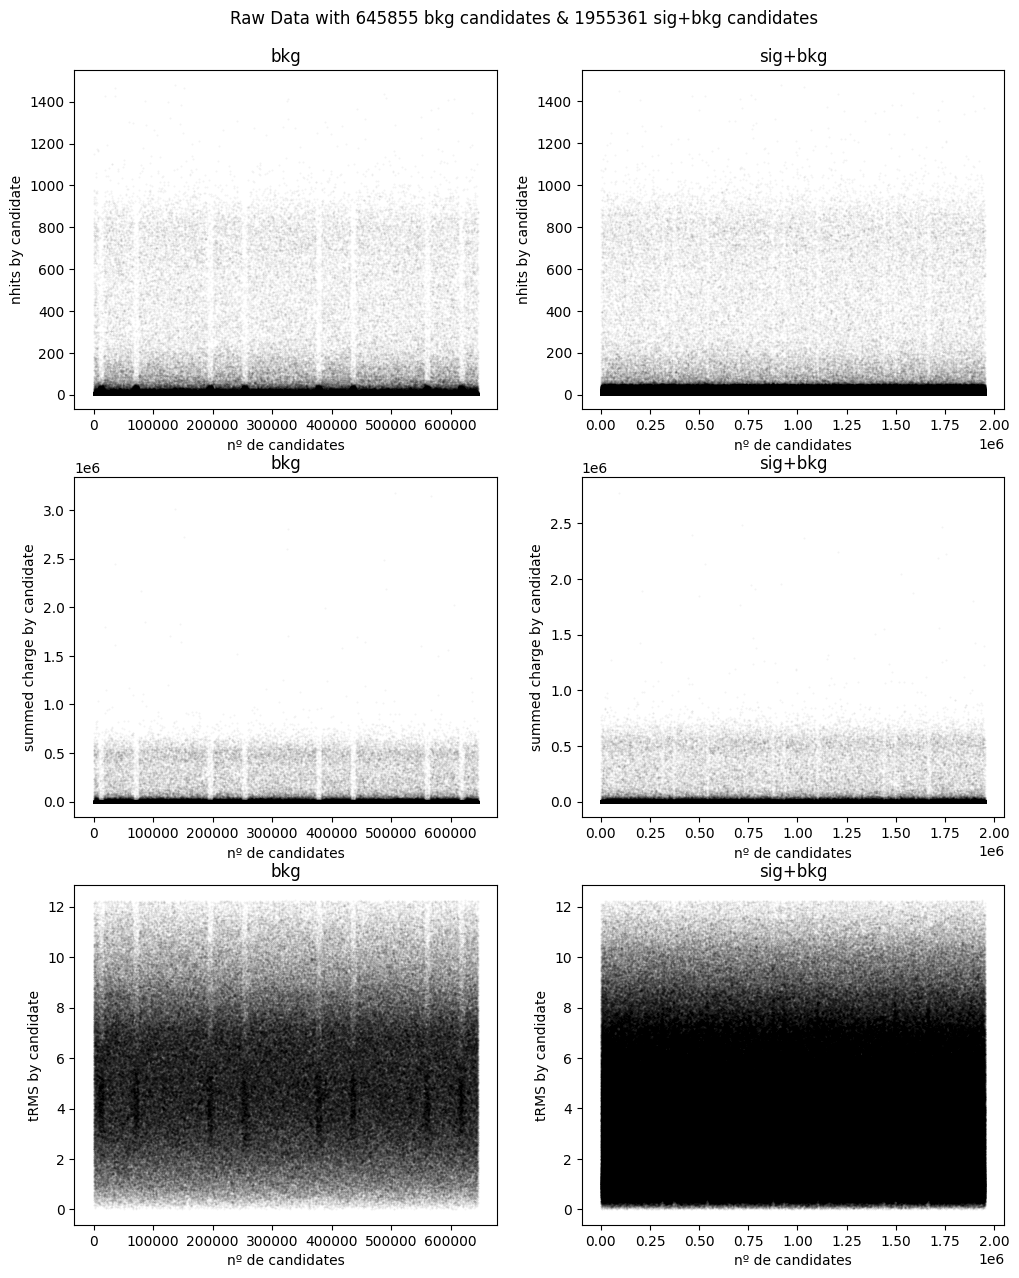

In [58]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg")

subplot(3)
plt.scatter(total_charge_by_candidate_bkg.index, total_charge_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("summed charge by candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_candidate_sig.index, total_charge_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("summed charge by candidate")
plt.title("sig+bkg")

subplot(5)
plt.scatter(total_trms_by_candidate_bkg.index, total_trms_by_candidate_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("tRMS by candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_candidate_sig.index, total_trms_by_candidate_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("tRMS by candidate")
plt.title("sig+bkg")

plt.suptitle(f"Raw Data with {len(data_by_candidate_bkg)} bkg candidates & {len(data_by_candidate_sig)} sig+bkg candidates", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_contaminadas.png", dpi=500, bbox_inches="tight")

## Muestras de candidates descontaminadas

Utilizaremos el scatter "nº total de hits de cada candidate vs nº de candidate" para eliminar los candidates que no nos interesan y quedarnos con los candidates buenos. Hago de nuevo este scatter:

Text(0.5, 0.98, 'nhits by candidate vs nº de candidate')

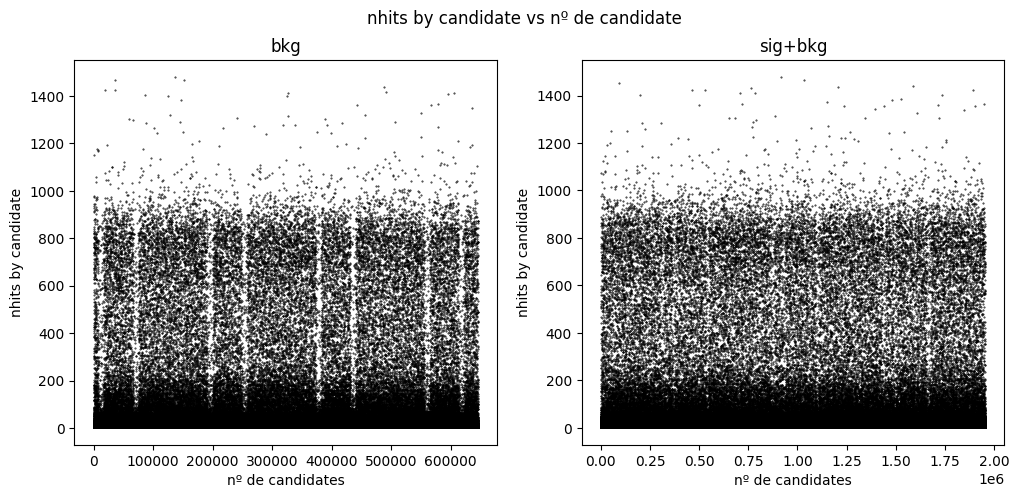

In [59]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.9)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.2, alpha=0.9)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg")

plt.suptitle("nhits by candidate vs nº de candidate")

Vemos que es evidente que los spills tienen una periodicidad, esto podría inspeccionarlo más a fondo pero de momento voy solo a quitarlos (JA me dijo que es por cómo el algoritmo nuevo recopila los datos). Aquí no hay valores saturantes. Además, en bkg se miden muchos eventos que registran entre 500-1000 hits, esto tiene que ser ruido de una fuente externa porque es imposible que sea señal.

Que se hayan quitado los spills es por algo que hizo Diego. Como el código se vuelve loco si intento quitar candidates de lo que eran los spills mejor los dejo como están.

In [8]:
#quiero quitar los spills y los que saturan
#lo lógico primero es bucar cuál es el valor exacto de saturación:

max_value_of_total_nhits_by_candidate_bkg = total_nhits_by_candidate_bkg.max()  #aquí .max() va con () porque realiza un cálculo
min_value_of_total_nhits_by_candidate_bkg = total_nhits_by_candidate_bkg.min()  #aquí .min() va con () porque realiza un cálculo

print(f"{max_value_of_total_nhits_by_candidate_bkg} es el valor máximo de nº de hits en los candidates para bkg")
print(f"{min_value_of_total_nhits_by_candidate_bkg} es el valor mínimo de nº de hits en los candidates para bkg")

#vemos con el valor máximo y cambiando el alpha que no hay valores saturantes

#igual para signal
max_value_of_total_nhits_by_candidate_sig = total_nhits_by_candidate_sig.max()
min_value_of_total_nhits_by_candidate_sig = total_nhits_by_candidate_sig.min()

print(f"{max_value_of_total_nhits_by_candidate_sig} es el valor máximo de nº de hits en los candidates para sig+bkg")
print(f"{min_value_of_total_nhits_by_candidate_sig} es el valor mínimo de nº de hits en los candidates para sig+bkg")

1479 es el valor máximo de nº de hits en los candidates para bkg
3 es el valor mínimo de nº de hits en los candidates para bkg
1477 es el valor máximo de nº de hits en los candidates para sig+bkg
3 es el valor mínimo de nº de hits en los candidates para sig+bkg


### Quitar spills bkg

(545000.0, 635000.0)

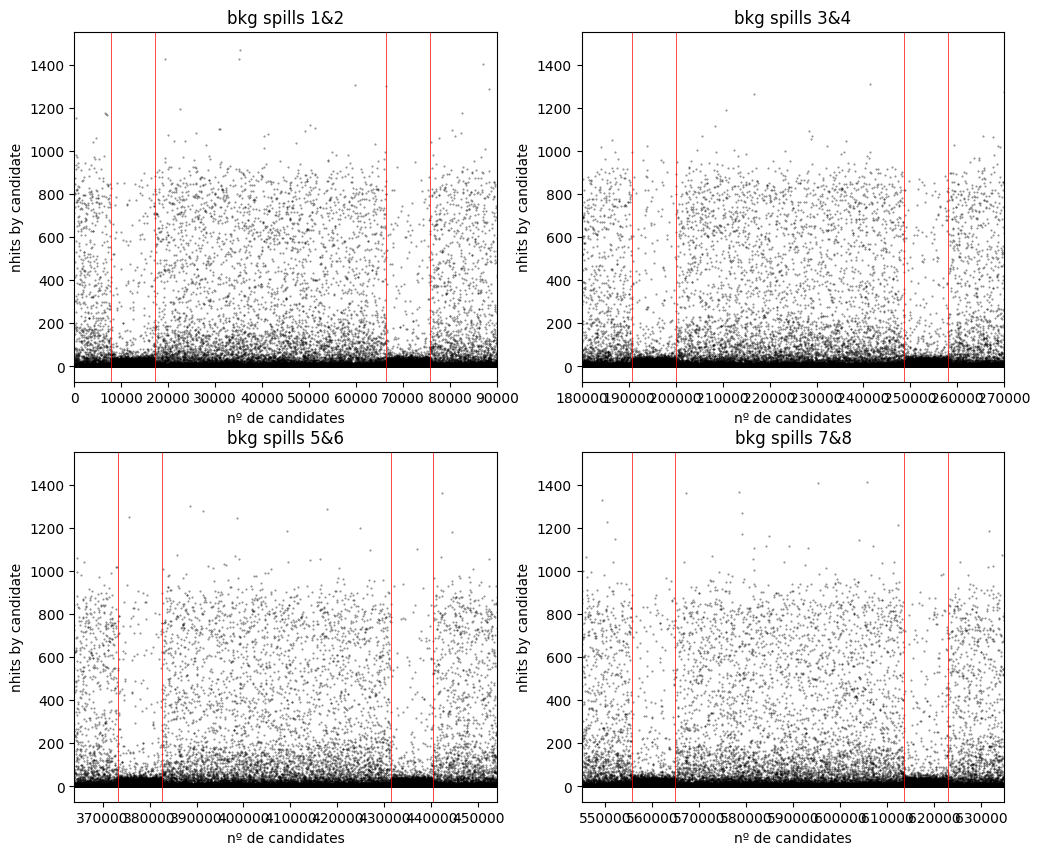

In [60]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(4)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg spills 1&2")

x_lines_spill1_bkg = [7750, 17100]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_bkg = [66400, 75750]      #configuro el intervalo igual para los dos: 9350
for x in x_lines_spill1_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0, 90000) #configuro para ver el mismo intervalo siempre en el eje x: 90000

subplot(2)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg spills 3&4")

x_lines_spill3_bkg = [190800, 200150]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill4_bkg = [248700, 258050]
for x in x_lines_spill3_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill4_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(180000, 270000)

subplot(3)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg spills 5&6")

x_lines_spill5_bkg = [373270, 382620]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill6_bkg = [431400, 440250]
for x in x_lines_spill5_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill6_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(364000, 454000)

subplot(4)
plt.scatter(total_nhits_by_candidate_bkg.index, total_nhits_by_candidate_bkg.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg spills 7&8")

x_lines_spill7_bkg = [555700, 564850]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_bkg = [613700, 623050]
for x in x_lines_spill7_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_bkg:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(545000, 635000)


### Quitar spills sig+bkg

Text(0.5, 1.0, 'sig+bkg')

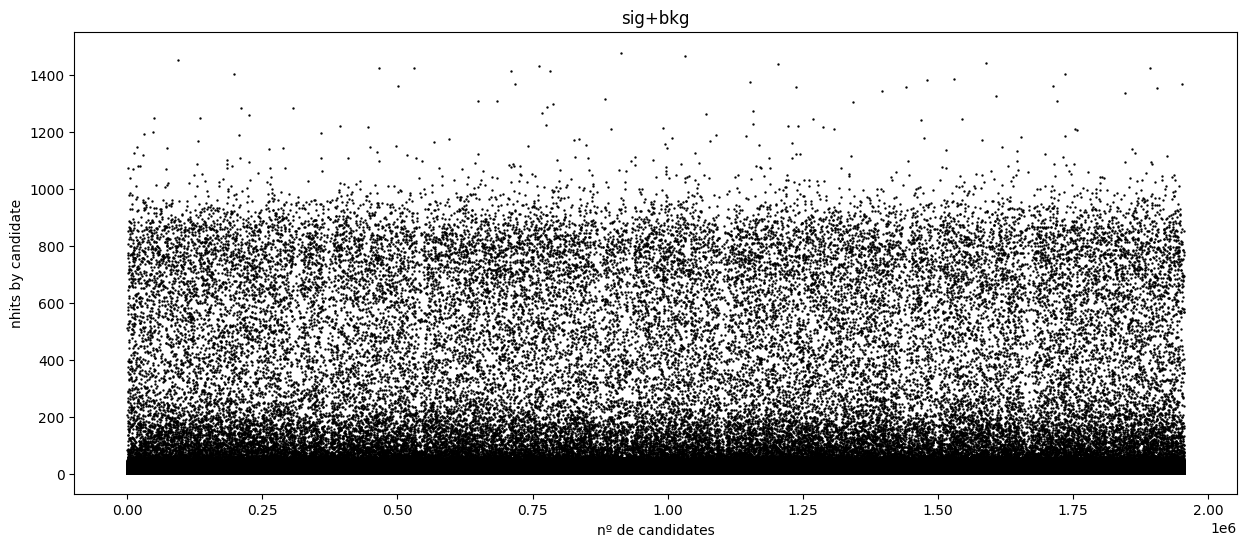

In [61]:
plt.figure(figsize=(15,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg")

(200000.0, 750000.0)

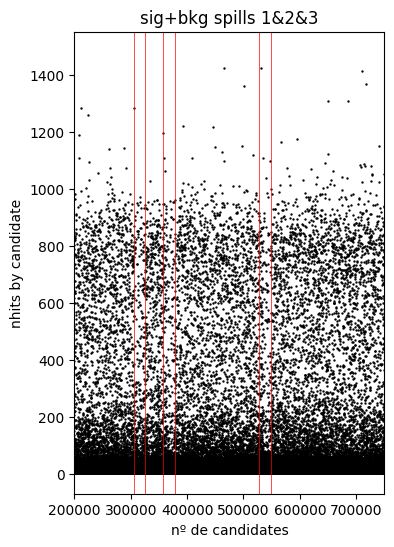

In [67]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 1&2&3")

x_lines_spill1_sig = [305000, 325000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill2_sig = [358000, 378000]      #configuro el intervalo igual para los dos: 430
x_lines_spill3_sig = [528000, 548000]
for x in x_lines_spill1_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill3_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.2e6, 0.75e6)

(750000.0, 1300000.0)

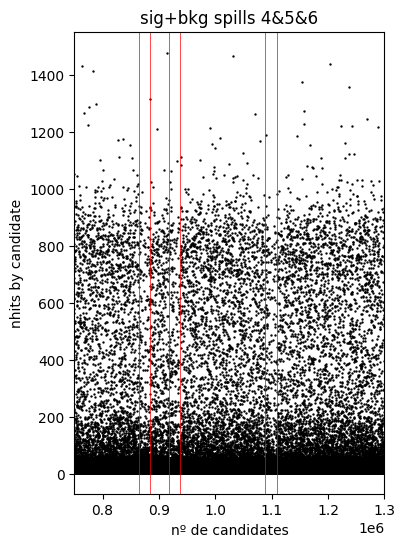

In [66]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 4&5&6")

x_lines_spill4_sig = [865000, 885000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill5_sig = [917000, 937000]      #configuro el intervalo igual para los dos: 430
x_lines_spill6_sig = [1089000, 1109000]
for x in x_lines_spill4_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill5_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill6_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.75e6, 1.3e6)

(1300000.0, 1850000.0)

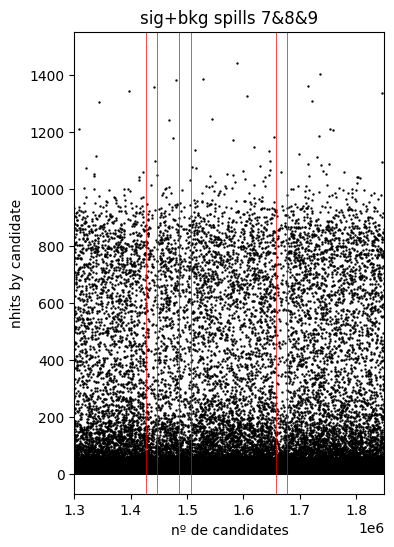

In [68]:
plt.figure(figsize=(4,6))
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 7&8&9")

x_lines_spill7_sig = [1427000, 1447000]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
x_lines_spill8_sig = [1486000, 1506000]      #configuro el intervalo igual para los dos: 430
x_lines_spill9_sig = [1657000, 1677000]
for x in x_lines_spill7_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill9_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(1.30E+06, 1.85E+06)

(1300000.0, 1850000.0)

<Figure size 1200x1000 with 0 Axes>

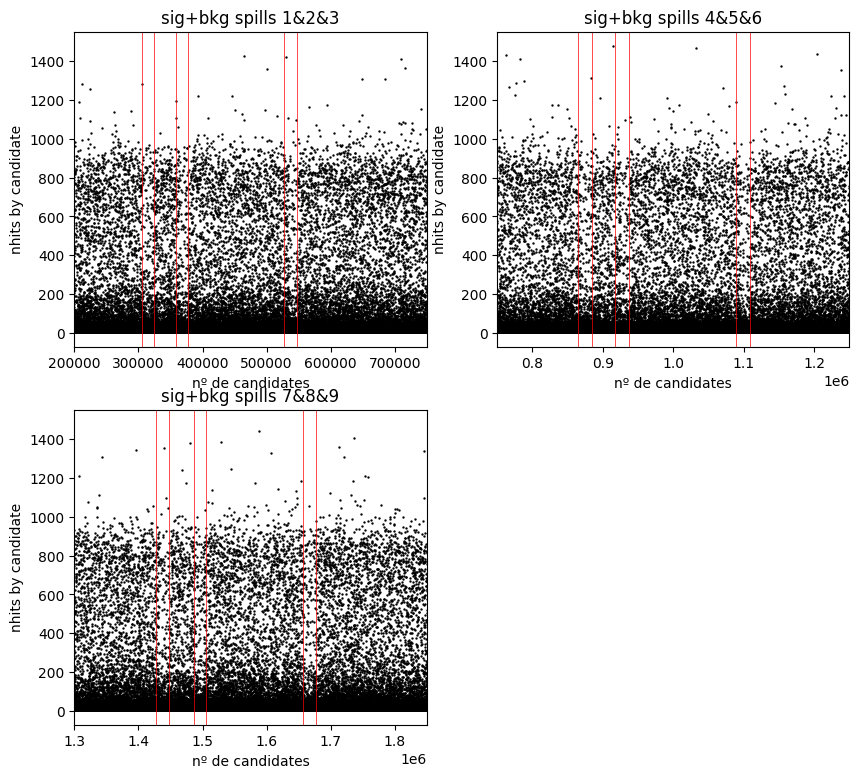

In [69]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(3)
plt.figure(figsize=(10,9))
subplot(1)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 1&2&3")

x_lines_spill1_sig = [305000, 325000]     
x_lines_spill2_sig = [358000, 378000]      
x_lines_spill3_sig = [528000, 548000]
for x in x_lines_spill1_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill2_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill3_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.2e6, 0.75e6)

subplot(2)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 4&5&6")

x_lines_spill4_sig = [865000, 885000]     
x_lines_spill5_sig = [917000, 937000]      
x_lines_spill6_sig = [1089000, 1109000]
for x in x_lines_spill4_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill5_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill6_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(0.75e6, 1.25e6)

subplot(3)
plt.scatter(total_nhits_by_candidate_sig.index, total_nhits_by_candidate_sig.values, s=0.5, alpha=1)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("sig+bkg spills 7&8&9")

x_lines_spill7_sig = [1427000, 1447000]     
x_lines_spill8_sig = [1486000, 1506000]      
x_lines_spill9_sig = [1657000, 1677000]
for x in x_lines_spill7_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 
for x in x_lines_spill8_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)
for x in x_lines_spill9_sig:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5)

plt.xlim(1.30E+06, 1.85E+06)


In [71]:
x_min_s1_bkg = 7750; x_max_s1_bkg = 17100
x_min_s2_bkg = 66400; x_max_s2_bkg = 75750
x_min_s3_bkg = 190800; x_max_s3_bkg = 200150
x_min_s4_bkg = 248700; x_max_s4_bkg = 258050
x_min_s5_bkg = 373270; x_max_s5_bkg = 382620
x_min_s6_bkg = 431400; x_max_s6_bkg = 440250
x_min_s7_bkg = 555700; x_max_s7_bkg = 564850
x_min_s8_bkg = 613700; x_max_s8_bkg = 623050

x_min_s1_sig = 305000; x_max_s1_sig = 325000
x_min_s2_sig = 358000; x_max_s2_sig = 378000
x_min_s3_sig = 528000; x_max_s3_sig = 548000
x_min_s4_sig = 865000; x_max_s4_sig = 885000
x_min_s5_sig = 917000; x_max_s5_sig = 937000
x_min_s6_sig = 1089000; x_max_s6_sig = 1109000
x_min_s7_sig = 1427000; x_max_s7_sig = 1447000
x_min_s8_sig = 1486000; x_max_s8_sig = 1506000
x_min_s9_sig = 1657000; x_max_s9_sig = 1677000

#series que hay que quitar
spill_1_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s1_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s1_bkg)]
spill_2_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s2_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s2_bkg)]
spill_3_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s3_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s3_bkg)]
spill_4_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s4_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s4_bkg)]
spill_5_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s5_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s5_bkg)]
spill_6_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s6_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s6_bkg)]
spill_7_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s7_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s7_bkg)]
spill_8_bkg = total_nhits_by_candidate_bkg[(total_nhits_by_candidate_bkg.index >= x_min_s8_bkg) & (total_nhits_by_candidate_bkg.index <= x_max_s8_bkg)]

spill_1_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s1_sig) & (total_nhits_by_candidate_sig.index <= x_max_s1_sig)]
spill_2_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s2_sig) & (total_nhits_by_candidate_sig.index <= x_max_s2_sig)]
spill_3_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s3_sig) & (total_nhits_by_candidate_sig.index <= x_max_s3_sig)]
spill_4_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s4_sig) & (total_nhits_by_candidate_sig.index <= x_max_s4_sig)]
spill_5_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s5_sig) & (total_nhits_by_candidate_sig.index <= x_max_s5_sig)]
spill_6_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s6_sig) & (total_nhits_by_candidate_sig.index <= x_max_s6_sig)]
spill_7_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s7_sig) & (total_nhits_by_candidate_sig.index <= x_max_s7_sig)]
spill_8_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s8_sig) & (total_nhits_by_candidate_sig.index <= x_max_s8_sig)]
spill_9_sig = total_nhits_by_candidate_sig[(total_nhits_by_candidate_sig.index >= x_min_s9_sig) & (total_nhits_by_candidate_sig.index <= x_max_s9_sig)]

#hay que concatenar sus índices, NO SUMAR.
combined_series_bkg = pd.concat([spill_1_bkg, spill_2_bkg, spill_3_bkg, spill_4_bkg, spill_5_bkg, spill_6_bkg, spill_7_bkg, spill_8_bkg]) 
combined_series_sig = pd.concat([spill_1_sig, spill_2_sig, spill_3_sig, spill_4_sig, spill_5_sig, spill_6_sig, spill_7_sig, spill_8_sig, spill_9_sig])

total_nhits_by_candidate_bkg_clean = total_nhits_by_candidate_bkg.drop(combined_series_bkg.index)
total_charge_by_candidate_bkg_clean = total_charge_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_candidate_bkg_clean = total_trms_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_clean.index]


total_nhits_by_candidate_sig_clean = total_nhits_by_candidate_sig.drop(combined_series_sig.index)
total_charge_by_candidate_sig_clean = total_charge_by_candidate_sig.loc[total_nhits_by_candidate_sig_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_candidate_sig_clean = total_trms_by_candidate_sig.loc[total_nhits_by_candidate_sig_clean.index]

###

print(f"Hemos juntado en una pd.Series con {len(combined_series_bkg)} candidates en los 8 spills de bkg, que representa el {len(combined_series_bkg)/len(total_nhits_by_candidate_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_candidate_bkg)-len(combined_series_bkg)} candidates que representan el {(len(total_nhits_by_candidate_bkg)-len(combined_series_bkg))/len(total_nhits_by_candidate_bkg)*100:.4f}% de la muestra inicial de bkg")
print(f"En total, hemos quitado {len(total_nhits_by_candidate_bkg)-len(total_charge_by_candidate_bkg_clean)} candidates de bkg")

print("\n")

print(f"Para sig+bkg tenemos {len(combined_series_sig)} candidates en los 9 spills que hay en sig+bkg, que representa el {len(combined_series_sig)/len(total_nhits_by_candidate_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_candidate_sig)-len(combined_series_sig)} candidates que representan el {(len(total_nhits_by_candidate_sig)-len(combined_series_sig))/len(total_nhits_by_candidate_sig)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"En total, hemos quitado {len(total_nhits_by_candidate_sig)-len(total_charge_by_candidate_sig_clean)} candidates de sig+bkg")


Hemos juntado en una pd.Series con 74108 candidates en los 8 spills de bkg, que representa el 11.4744% de la muestra inicial de bkg
Nos queda la pd.Series descontaminada (clean), con 571747 candidates que representan el 88.5256% de la muestra inicial de bkg
En total, hemos quitado 74108 candidates de bkg


Para sig+bkg tenemos 180009 candidates en los 9 spills que hay en sig+bkg, que representa el 9.2059% de la muestra inicial de sig+bkg
Nos queda la pd.Series descontaminada (clean), con 1775352 candidates que representan el 90.7941% de la muestra inicial de sig+bkg
En total, hemos quitado 180009 candidates de sig+bkg


### Recap muestras descontaminadas

Text(0.5, 0.92, 'Clean Data with 571747 bkg candidates & 1775352 sig+bkg candidates')

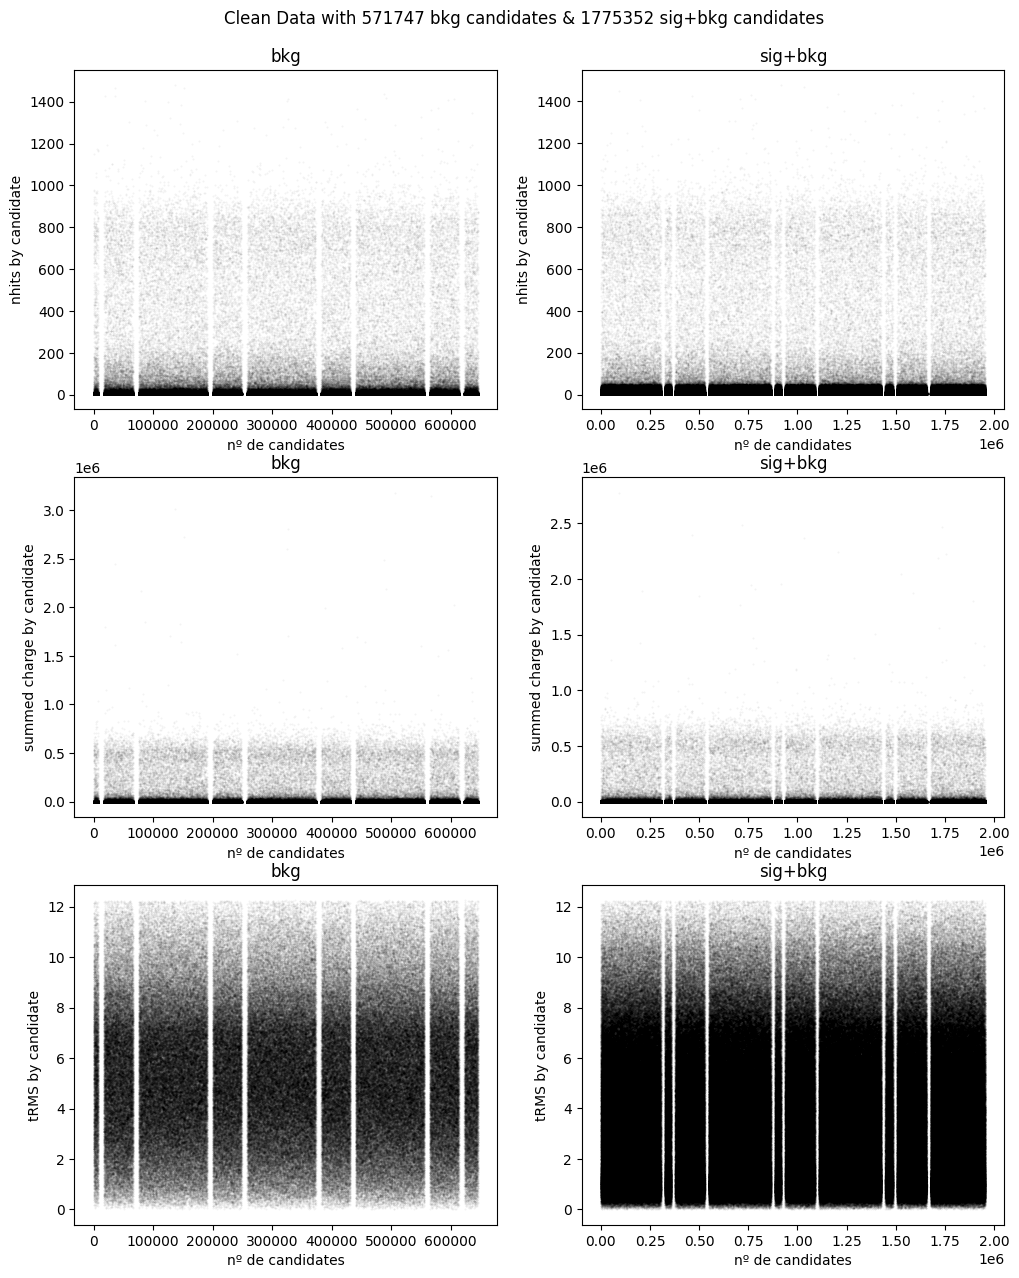

In [70]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_candidate_bkg_clean.index, total_nhits_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("nhits by candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_candidate_sig_clean.index, total_nhits_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")    
plt.ylabel("nhits by candidate")
plt.title("sig+bkg")


subplot(3)
plt.scatter(total_charge_by_candidate_bkg_clean.index, total_charge_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("summed charge by candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_candidate_sig_clean.index, total_charge_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("summed charge by candidate")
plt.title("sig+bkg")


subplot(5)
plt.scatter(total_trms_by_candidate_bkg_clean.index, total_trms_by_candidate_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("tRMS by candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_candidate_sig_clean.index, total_trms_by_candidate_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates")
plt.ylabel("tRMS by candidate")
plt.title("sig+bkg")

plt.suptitle(f"Clean Data with {len(total_nhits_by_candidate_bkg)-len(combined_series_bkg)} bkg candidates & {len(total_nhits_by_candidate_sig)-len(combined_series_sig)} sig+bkg candidates", y=0.92)

#plt.savefig(f"{output_directory}/Muestras_descontaminadas.png", dpi=500, bbox_inches="tight")

# Distributions

## Obtención de distribuciones

### Distribución de hits por candidate

Text(0.5, 0.98, 'Distribución de nhits by candidate log yscale')

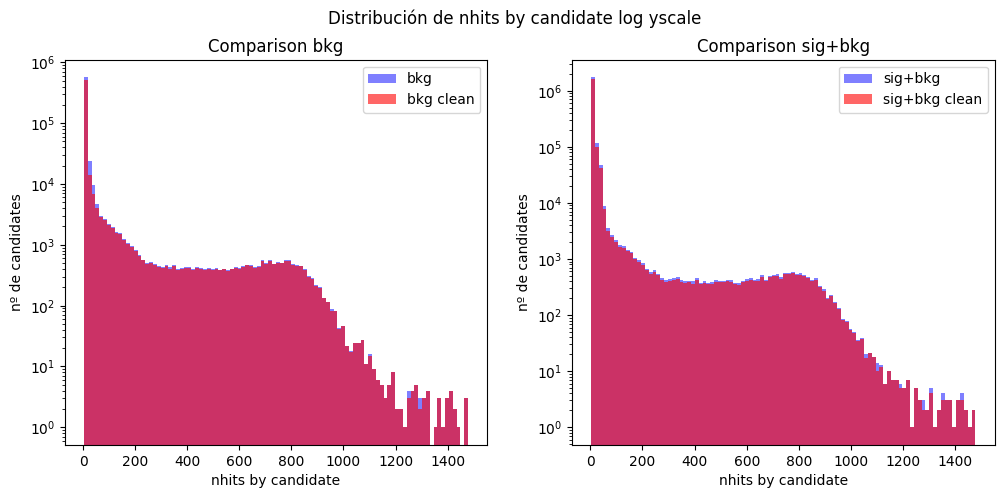

In [72]:
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("log")

subplot(1)
plt.hist(total_nhits_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", alpha=0.5, color="b")   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", alpha=0.6, color="r")
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", alpha=0.5, color="b")
plt.hist(total_nhits_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", alpha=0.6, color="r")
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
plt.legend()

plt.suptitle("Distribución de nhits by candidate log yscale")

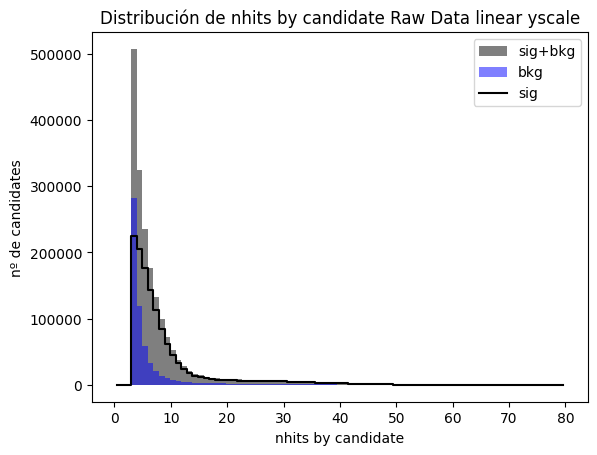

In [73]:
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 81, color="k", range=(0,80), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 81, color="b", range=(0,80), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, where="mid", label="sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.title("Distribución de nhits by candidate Raw Data linear yscale")
plt.yscale("linear")
plt.legend()

### Distribución de carga total por candidate

Text(0.5, 0.98, 'Distribución de summed charge by candidate log yscale')

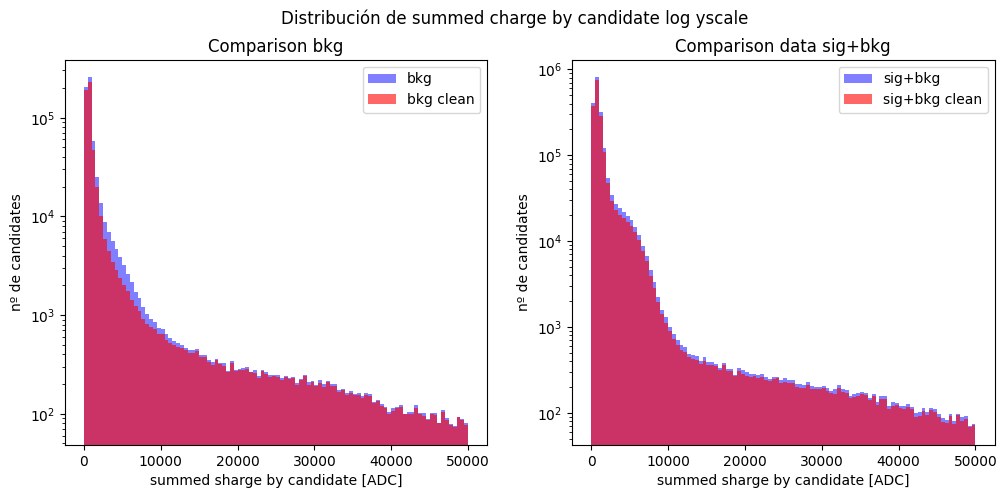

In [74]:
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("log")

hist_range = (0, 50e3)

subplot(1)
plt.hist(total_charge_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("summed sharge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_charge_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("summed sharge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.title("Comparison data sig+bkg")
plt.legend()

plt.suptitle("Distribución de summed charge by candidate log yscale")

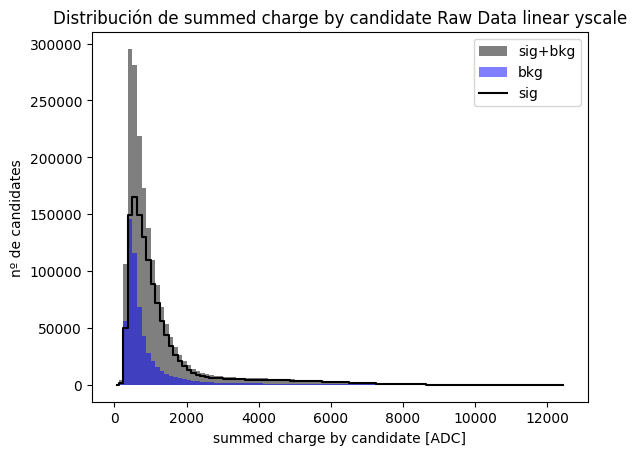

In [75]:
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_candidate_sig, 100,range=(0,12500), color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_candidate_bkg, 100,range=(0,12500), color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma

bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, where="mid", label="sig", color="k")

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.title("Distribución de summed charge by candidate Raw Data linear yscale")
plt.yscale("linear")
plt.legend()

### Distribución de tRMS por candidate

Text(0.5, 0.98, 'Distribución de tRMS by candidate linear yscale')

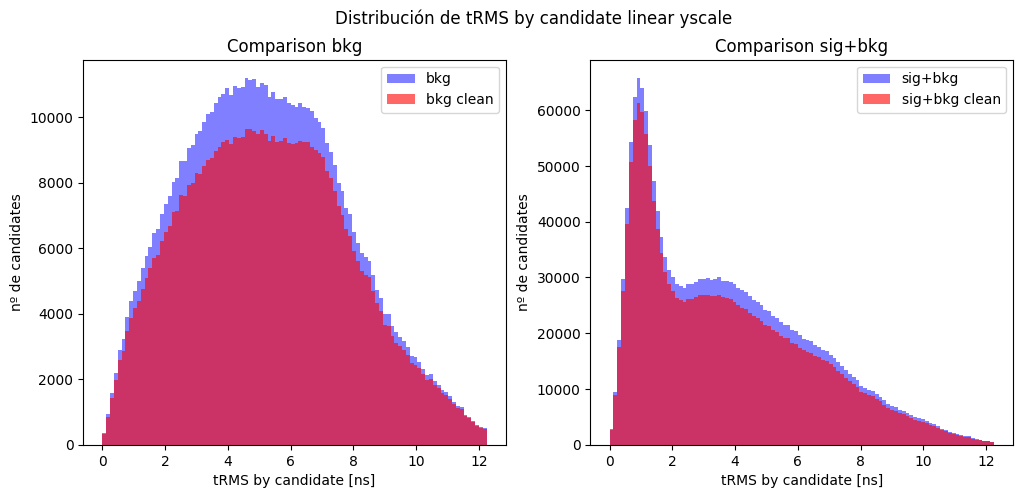

In [76]:
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
plt.hist(total_trms_by_candidate_bkg, 100, histtype="stepfilled", alpha=0.5, label="bkg", color="b")
plt.hist(total_trms_by_candidate_bkg_clean, 100, histtype="stepfilled", alpha=0.6, label="bkg clean", color="r")
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_trms_by_candidate_sig, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg", color="b")
plt.hist(total_trms_by_candidate_sig_clean, 100, histtype="stepfilled", alpha=0.6, label="sig+bkg clean", color="r")
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
plt.legend()

plt.suptitle("Distribución de tRMS by candidate linear yscale")



La tRMS es la desviación estándar de los tiempos de llegada de los hits en un candidate. Si los hits que forman un candidate llegaran a la vez, el tRMS sería cero, i.e., cuanto más dispersos en el tiempo, mayor será la tRMS. Vemos que el pico corresponde a que hay muchos candidates con tRMS pequeña (los hits llegan casi a la vez). Que haya esta diferencia tan marcada entre bkg y sig+bkg sugiere que el detector tiene buena resolución para identificar candidates deseados basándose en el tiempo.

Si quiero hacer un corte para quedarme solo con los candidates más probables de ser reales lo haría en tRMS < 2 [ns]: conservo gran parte de sig (pico) y elimino gran parte del bkg.

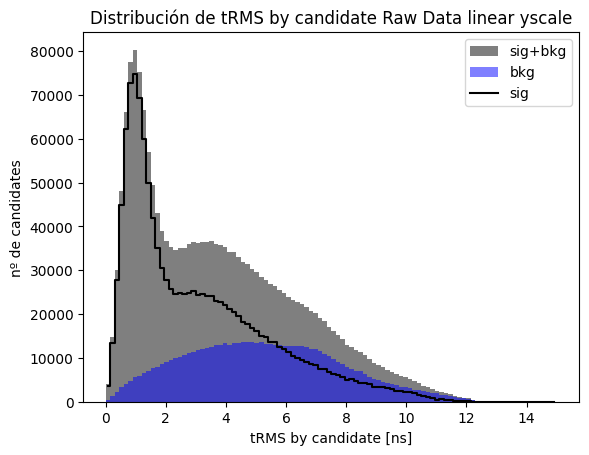

In [77]:
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_candidate_sig, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_candidate_bkg, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, where="mid", label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???

plt.title("Distribución de tRMS by candidate Raw Data linear yscale")
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

plt.yscale("linear")

## RECAP Distribuciones Raw Data

Text(0.5, 0.92, 'Raw vs Clean Samples with log yscale')

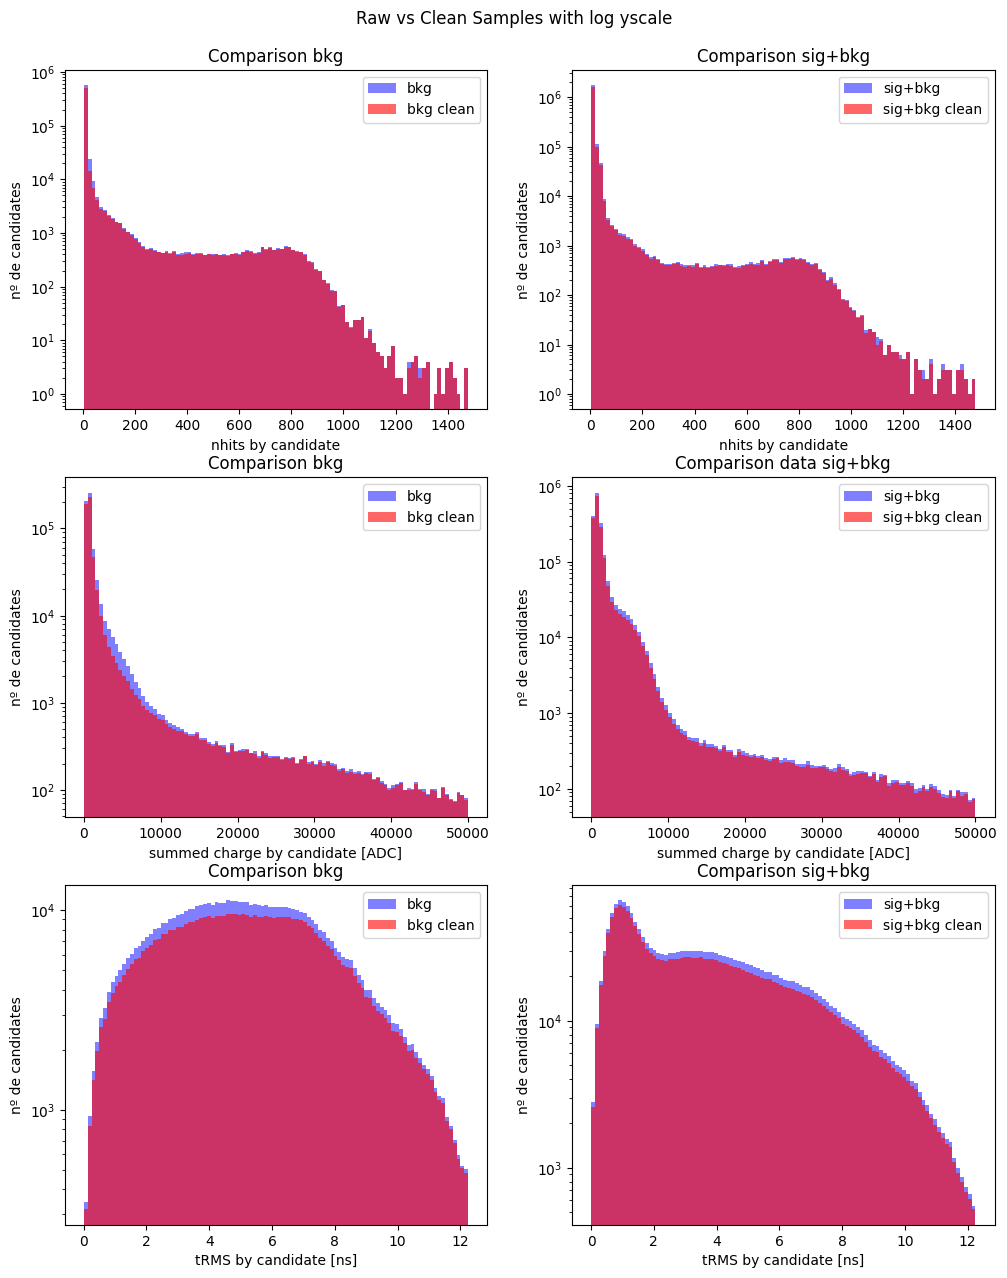

In [78]:
subplot = pltext.canvas(6)

for i in [1, 2,3,4,5,6]:
    subplot(i)
    #plt.yscale("linear")
    plt.yscale("log")

subplot(1)
plt.hist(total_nhits_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", alpha=0.5, color="b")   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", alpha=0.6, color="r")
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", alpha=0.5, color="b")
plt.hist(total_nhits_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", alpha=0.6, color="r")
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
plt.legend()

subplot(3)
plt.hist(total_charge_by_candidate_bkg, 100, histtype="stepfilled", label="bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_bkg_clean, 100, histtype="stepfilled", label="bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(4)
plt.hist(total_charge_by_candidate_sig, 100, histtype="stepfilled", label="sig+bkg", range=hist_range, alpha=0.5, color="b")   #100 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_candidate_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", range=hist_range, alpha=0.6, color="r")
plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.title("Comparison data sig+bkg")
plt.legend()

subplot(5)
plt.hist(total_trms_by_candidate_bkg, 100, histtype="stepfilled", alpha=0.5, label="bkg", color="b")
plt.hist(total_trms_by_candidate_bkg_clean, 100, histtype="stepfilled", alpha=0.6, label="bkg clean", color="r")
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison bkg")
plt.legend()

subplot(6)
plt.hist(total_trms_by_candidate_sig, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg", color="b")
plt.hist(total_trms_by_candidate_sig_clean, 100, histtype="stepfilled", alpha=0.6, label="sig+bkg clean", color="r")
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("Comparison sig+bkg")
plt.legend()

plt.suptitle("Raw vs Clean Samples with log yscale", y=0.92)


Text(0.5, 0.92, 'Raw Distributions linear vs log yscale')

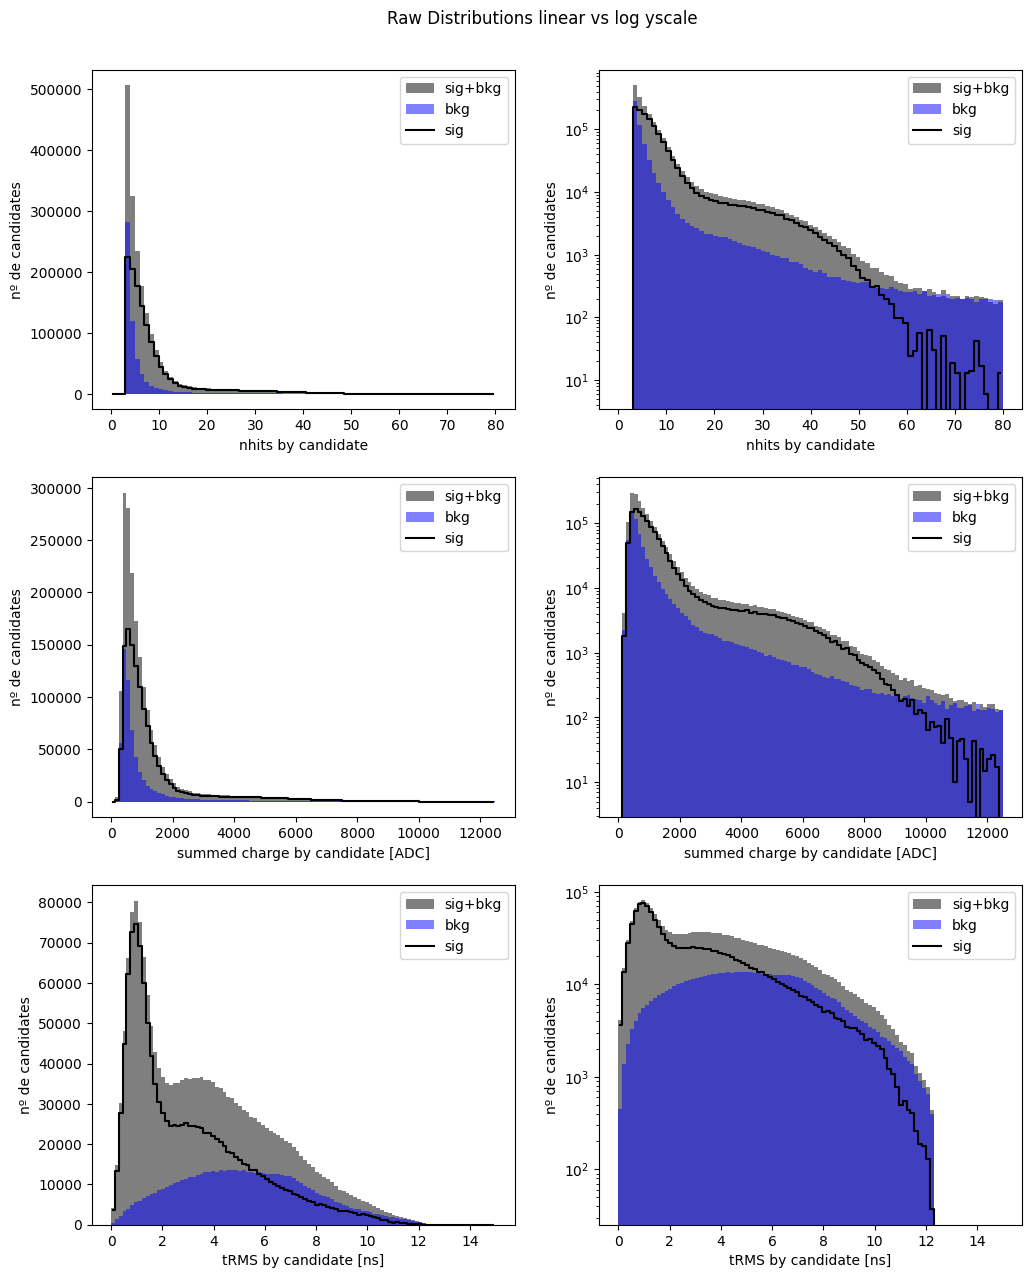

In [80]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 81, color="k", range=(0,80), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 81, color="b", range=(0,80), histtype = "stepfilled" ,alpha=0.5, label="bkg")
bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, where="mid", label="sig", color="k") ;
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.yscale("linear")
plt.legend()

subplot(2)
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_candidate_sig, 81, color="k", range=(0,80), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_candidate_bkg, 81, color="b", range=(0,80), histtype = "stepfilled" ,alpha=0.5, label="bkg")
bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, where="mid", label="sig", color="k") ;
plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.yscale("log")
plt.legend()

subplot(3)
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_candidate_sig, 100,range=(0,12500), color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_candidate_bkg, 100,range=(0,12500), color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma
bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, where="mid", label="sig", color="k")
plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.yscale("linear")
plt.legend()

subplot(4)
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_candidate_sig, 100,range=(0,12500), color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_candidate_bkg, 100,range=(0,12500), color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma
bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, where="mid", label="sig", color="k")
plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.yscale("log")
plt.legend()

subplot(5)
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_candidate_sig, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_candidate_bkg, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")
bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, where="mid", label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.yscale("linear")
plt.legend()

subplot(6)
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_candidate_sig, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_candidate_bkg, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")
bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, where="mid", label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.yscale("log")
plt.legend()

plt.suptitle("Raw Distributions linear vs log yscale", y=0.92)


# Cuts

## Cortes en nhits por candidate

In [81]:
#hago los cortes: busco los candidates con número de hits entre 5(10) y 60 hits.
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: un cut
#tengo q hacer dos para los dos límites inferiores que me pidieron

cut_5_bkg = (total_nhits_by_candidate_bkg > 5) & (total_nhits_by_candidate_bkg <= 60)
cut_5_sig = (total_nhits_by_candidate_sig > 5) & (total_nhits_by_candidate_sig <= 60)  #no puedo usar el mismo corte para los dos porq son series diferentes

cut_10_bkg = (total_nhits_by_candidate_bkg > 10) & (total_nhits_by_candidate_bkg <= 60)
cut_10_sig = (total_nhits_by_candidate_sig > 10) & (total_nhits_by_candidate_sig <= 60)


total_nhits_by_candidate_sig_cut_5 = total_nhits_by_candidate_sig[cut_5_sig]
total_nhits_by_candidate_bkg_cut_5 = total_nhits_by_candidate_bkg[cut_5_bkg]

total_nhits_by_candidate_sig_cut_10 = total_nhits_by_candidate_sig[cut_10_sig]
total_nhits_by_candidate_bkg_cut_10 = total_nhits_by_candidate_bkg[cut_10_bkg]

total_charge_by_candidate_sig_cut_5 = total_charge_by_candidate_sig.loc[total_nhits_by_candidate_sig_cut_5.index]
total_charge_by_candidate_bkg_cut_5 = total_charge_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_cut_5.index]

total_charge_by_candidate_sig_cut_10 = total_charge_by_candidate_sig.loc[total_nhits_by_candidate_sig_cut_10.index]
total_charge_by_candidate_bkg_cut_10 = total_charge_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_cut_10.index]

total_trms_by_candidate_sig_cut_5 = total_trms_by_candidate_sig.loc[total_nhits_by_candidate_sig_cut_5.index]
total_trms_by_candidate_bkg_cut_5 = total_trms_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_cut_5.index]

total_trms_by_candidate_sig_cut_10 = total_trms_by_candidate_sig.loc[total_nhits_by_candidate_sig_cut_10.index]
total_trms_by_candidate_bkg_cut_10 = total_trms_by_candidate_bkg.loc[total_nhits_by_candidate_bkg_cut_10.index]

Text(0.5, 0.92, 'Distributions Raw Data con cut_5=(5,60) y cut_10=(10,60) en nhits linear yscale')

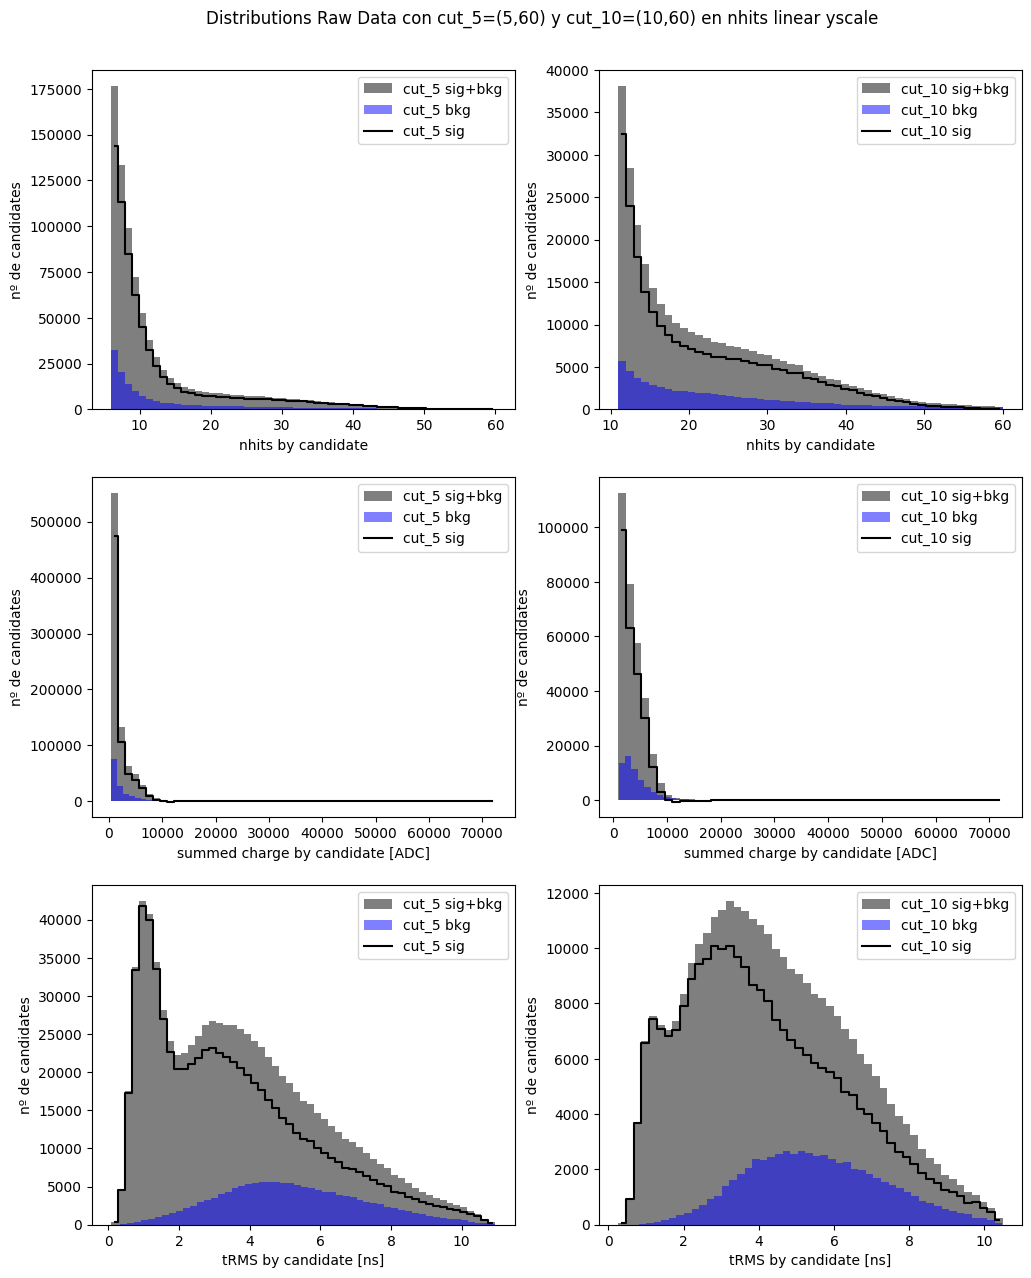

In [84]:
subplot = pltext.canvas(6)
for i in [1, 2,3,4,5,6]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
counts_sig_nhits_cut_5, edges_sig_nhits_cut_5, _ = plt.hist(total_nhits_by_candidate_sig_cut_5, 55, histtype="stepfilled", alpha=0.5, label="cut_5 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_5, edges_bkg_nhits_cut_5, _ = plt.hist(total_nhits_by_candidate_bkg_cut_5, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_5 bkg")

bin_centers_nhits_cut_5 = (edges_sig_nhits_cut_5[:-1] + edges_sig_nhits_cut_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_5, counts_sig_nhits_cut_5 - counts_bkg_nhits_cut_5, where="mid", label="cut_5 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()

subplot(2)
counts_sig_nhits_cut_10, edges_sig_nhits_cut_10, _ = plt.hist(total_nhits_by_candidate_sig_cut_10, 50, histtype="stepfilled", alpha=0.5, label="cut_10 sig+bkg") #50 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_10, edges_bkg_nhits_cut_10, _ = plt.hist(total_nhits_by_candidate_bkg_cut_10, 50, histtype = "stepfilled" ,alpha=0.5, label="cut_10 bkg")

bin_centers_nhits_cut_10 = (edges_sig_nhits_cut_10[:-1] + edges_sig_nhits_cut_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_10, counts_sig_nhits_cut_10 - counts_bkg_nhits_cut_10, where="mid", label="cut_10 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()

subplot(3)
counts_sig_charge_cut_5, edges_sig_charge_cut_5, _ = plt.hist(total_charge_by_candidate_sig_cut_5, 55, histtype="stepfilled", alpha=0.5, label="cut_5 sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_5, edges_bkg_charge_cut_5, _ = plt.hist(total_charge_by_candidate_bkg_cut_5, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_5 bkg")

bin_centers_charge_cut_5 = (edges_sig_charge_cut_5[:-1] + edges_sig_charge_cut_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_5, counts_sig_charge_cut_5 - counts_bkg_charge_cut_5, where="mid", label="cut_5 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()

subplot(4)
counts_sig_charge_cut_10, edges_sig_charge_cut_10, _ = plt.hist(total_charge_by_candidate_sig_cut_10, 50, histtype="stepfilled", alpha=0.5, label="cut_10 sig+bkg") #50 bins según nhits
counts_bkg_charge_cut_10, edges_bkg_charge_cut_10, _ = plt.hist(total_charge_by_candidate_bkg_cut_10, 50, histtype = "stepfilled" ,alpha=0.5, label="cut_10 bkg")

bin_centers_charge_cut_10 = (edges_sig_charge_cut_10[:-1] + edges_sig_charge_cut_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_10, counts_sig_charge_cut_10 - counts_bkg_charge_cut_10, where="mid", label="cut_10 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()

subplot(5)#para trms
counts_sig_trms_cut_5, edges_sig_trms_cut_5, _ = plt.hist(total_trms_by_candidate_sig_cut_5, 55, histtype="stepfilled", alpha=0.5, label="cut_5 sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_5, edges_bkg_trms_cut_5, _ = plt.hist(total_trms_by_candidate_bkg_cut_5, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_5 bkg")

bin_centers_trms_cut_5 = (edges_sig_trms_cut_5[:-1] + edges_sig_trms_cut_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_5, counts_sig_trms_cut_5 - counts_bkg_trms_cut_5, where="mid", label="cut_5 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

subplot(6)
counts_sig_trms_cut_10, edges_sig_trms_cut_10, _ = plt.hist(total_trms_by_candidate_sig_cut_10, 50, histtype="stepfilled", alpha=0.5, label="cut_10 sig+bkg") #50 bins según nhits
counts_bkg_trms_cut_10, edges_bkg_trms_cut_10, _ = plt.hist(total_trms_by_candidate_bkg_cut_10, 50, histtype = "stepfilled" ,alpha=0.5, label="cut_10 bkg")

bin_centers_trms_cut_10 = (edges_sig_trms_cut_10[:-1] + edges_sig_trms_cut_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_10, counts_sig_trms_cut_10 - counts_bkg_trms_cut_10, where="mid", label="cut_10 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

plt.suptitle("Distributions Raw Data con cut_5=(5,60) y cut_10=(10,60) en nhits linear yscale", y=0.92)


## Corte en carga total por candidate

In [85]:
#hago los cortes: busco los candidate con carga entre 0 y 100000 [ADC]. Creo que es mejor establecer 10000
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: un cut
#tengo q hacer dos para los dos límites inferiores que me pidieron

cut_charge_bkg = (total_charge_by_candidate_bkg > 0) & (total_charge_by_candidate_bkg <= 10000)
cut_charge_sig = (total_charge_by_candidate_sig > 0) & (total_charge_by_candidate_sig <= 10000)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_charge_by_candidate_sig_cut_charge = total_charge_by_candidate_sig[cut_charge_sig]
total_charge_by_candidate_bkg_cut_charge = total_charge_by_candidate_bkg[cut_charge_bkg]

total_nhits_by_candidate_sig_cut_charge = total_nhits_by_candidate_sig.loc[total_charge_by_candidate_sig_cut_charge.index]
total_nhits_by_candidate_bkg_cut_charge = total_nhits_by_candidate_bkg.loc[total_charge_by_candidate_bkg_cut_charge.index]

total_trms_by_candidate_sig_cut_charge = total_trms_by_candidate_sig.loc[total_charge_by_candidate_sig_cut_charge.index]
total_trms_by_candidate_bkg_cut_charge = total_trms_by_candidate_bkg.loc[total_charge_by_candidate_bkg_cut_charge.index]

Text(0.5, 0.96, 'Distributions Raw Data con cut_charge=(0,10000) en charge linear yscale')

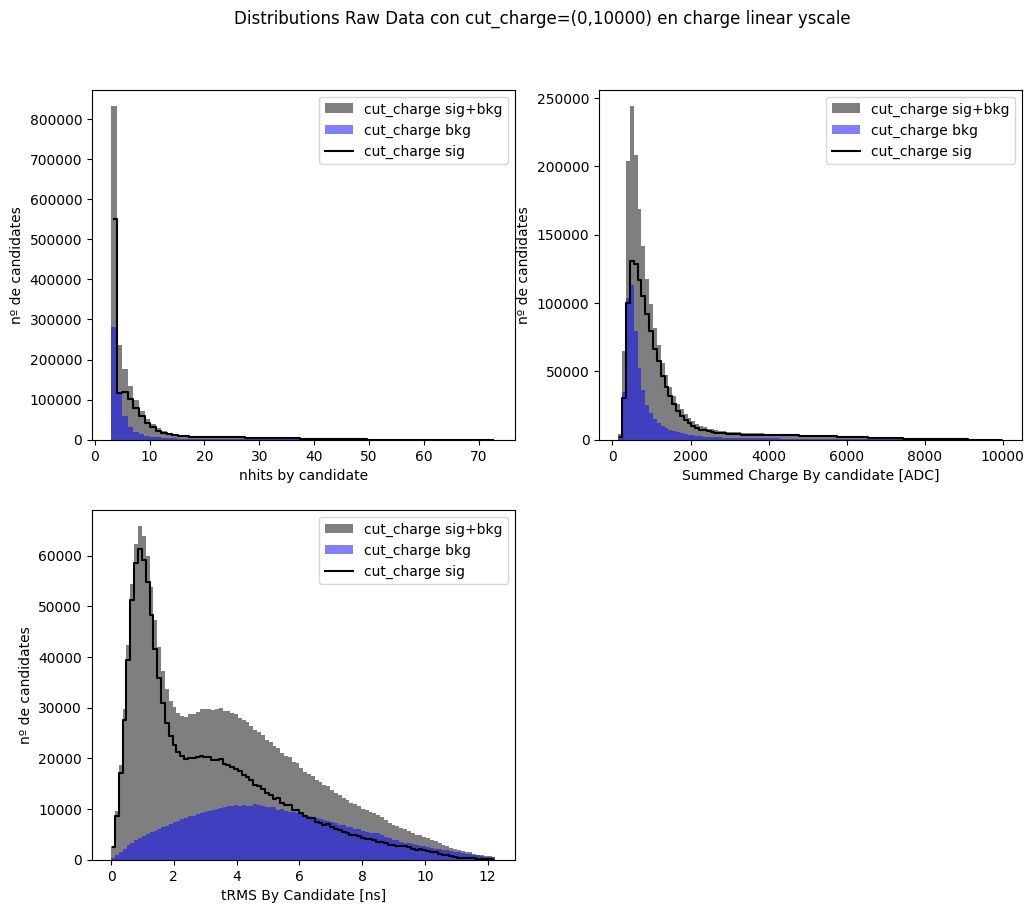

In [86]:
subplot = pltext.canvas(3)
for i in [1, 2,3]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
counts_sig_nhits_cut_charge, edges_sig_nhits_cut_charge, _ = plt.hist(total_nhits_by_candidate_sig_cut_charge, 69, histtype="stepfilled", alpha=0.5, label="cut_charge sig+bkg") #100 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_charge, edges_bkg_nhits_cut_charge, _ = plt.hist(total_nhits_by_candidate_bkg_cut_charge, 69, histtype = "stepfilled" ,alpha=0.5, label="cut_charge bkg")

bin_centers_nhits_cut_charge = (edges_sig_nhits_cut_charge[:-1] + edges_sig_nhits_cut_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_charge, counts_sig_nhits_cut_charge - counts_bkg_nhits_cut_charge, where="mid", label="cut_charge sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()


subplot(2)
counts_sig_charge_cut_charge, edges_sig_charge_cut_charge, _ = plt.hist(total_charge_by_candidate_sig_cut_charge, 100, histtype="stepfilled", alpha=0.5, label="cut_charge sig+bkg") #100 bins según nhits
counts_bkg_charge_cut_charge, edges_bkg_charge_cut_charge, _ = plt.hist(total_charge_by_candidate_bkg_cut_charge, 100, histtype = "stepfilled" ,alpha=0.5, label="cut_charge bkg")

bin_centers_charge_cut_charge = (edges_sig_charge_cut_charge[:-1] + edges_sig_charge_cut_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_charge, counts_sig_charge_cut_charge - counts_bkg_charge_cut_charge, where="mid", label="cut_charge sig", color="k") 

plt.xlabel("Summed Charge By candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()


subplot(3)#para trms
counts_sig_trms_cut_charge, edges_sig_trms_cut_charge, _ = plt.hist(total_trms_by_candidate_sig_cut_charge, 100, histtype="stepfilled", alpha=0.5, label="cut_charge sig+bkg") #100 bins según nhits
counts_bkg_trms_cut_charge, edges_bkg_trms_cut_charge, _ = plt.hist(total_trms_by_candidate_bkg_cut_charge, 100, histtype = "stepfilled" ,alpha=0.5, label="cut_charge bkg")

bin_centers_trms_cut_charge = (edges_sig_trms_cut_charge[:-1] + edges_sig_trms_cut_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_charge, counts_sig_trms_cut_charge - counts_bkg_trms_cut_charge, where="mid", label="cut_charge sig", color="k") 

plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()


plt.suptitle("Distributions Raw Data con cut_charge=(0,10000) en charge linear yscale", y=0.96)


## Corte en tRMS por candidate

In [87]:
#hago los cortes: busco los candidateos con carga entre 0 y 6 [ns].
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: un cut
#tengo q hacer dos para los dos límites inferiores que me pidieron

cut_trms_bkg = (total_trms_by_candidate_bkg > 0) & (total_trms_by_candidate_bkg <= 6)
cut_trms_sig = (total_trms_by_candidate_sig > 0) & (total_trms_by_candidate_sig <= 6)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_trms_by_candidate_sig_cut_trms = total_trms_by_candidate_sig[cut_trms_sig]
total_trms_by_candidate_bkg_cut_trms = total_trms_by_candidate_bkg[cut_trms_bkg]

total_nhits_by_candidate_sig_cut_trms = total_nhits_by_candidate_sig.loc[total_trms_by_candidate_sig_cut_trms.index]
total_nhits_by_candidate_bkg_cut_trms = total_nhits_by_candidate_bkg.loc[total_trms_by_candidate_bkg_cut_trms.index]

total_charge_by_candidate_sig_cut_trms = total_charge_by_candidate_sig.loc[total_trms_by_candidate_sig_cut_trms.index]
total_charge_by_candidate_bkg_cut_trms = total_charge_by_candidate_bkg.loc[total_trms_by_candidate_bkg_cut_trms.index]

Text(0.5, 0.96, 'Distributions Raw Data con cut_trms=(0,6) para tRMS linear yscale')

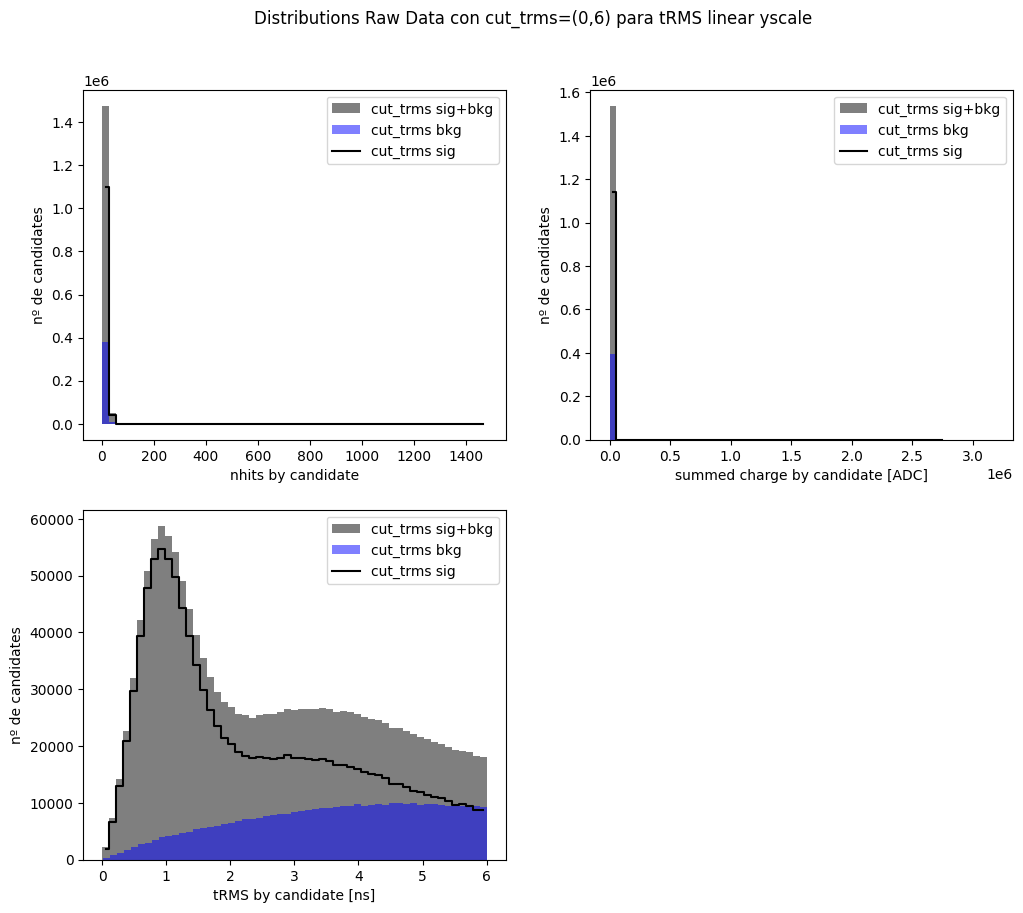

In [88]:
subplot = pltext.canvas(3)
for i in [1, 2,3]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
counts_sig_nhits_cut_trms, edges_sig_nhits_cut_trms, _ = plt.hist(total_nhits_by_candidate_sig_cut_trms, 55, histtype="stepfilled", alpha=0.5, label="cut_trms sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_trms, edges_bkg_nhits_cut_trms, _ = plt.hist(total_nhits_by_candidate_bkg_cut_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_trms bkg")

bin_centers_nhits_cut_trms = (edges_sig_nhits_cut_trms[:-1] + edges_sig_nhits_cut_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_trms, counts_sig_nhits_cut_trms - counts_bkg_nhits_cut_trms, where="mid", label="cut_trms sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()


subplot(2)
counts_sig_charge_cut_trms, edges_sig_charge_cut_trms, _ = plt.hist(total_charge_by_candidate_sig_cut_trms, 55, histtype="stepfilled", alpha=0.5, label="cut_trms sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_trms, edges_bkg_charge_cut_trms, _ = plt.hist(total_charge_by_candidate_bkg_cut_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_trms bkg")

bin_centers_charge_cut_trms = (edges_sig_charge_cut_trms[:-1] + edges_sig_charge_cut_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_trms, counts_sig_charge_cut_trms - counts_bkg_charge_cut_trms, where="mid", label="cut_trms sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()


subplot(3)#para trms
counts_sig_trms_cut_trms, edges_sig_trms_cut_trms, _ = plt.hist(total_trms_by_candidate_sig_cut_trms, 55, histtype="stepfilled", alpha=0.5, label="cut_trms sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_trms, edges_bkg_trms_cut_trms, _ = plt.hist(total_trms_by_candidate_bkg_cut_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_trms bkg")

bin_centers_trms_cut_trms = (edges_sig_trms_cut_trms[:-1] + edges_sig_trms_cut_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_trms, counts_sig_trms_cut_trms - counts_bkg_trms_cut_trms, where="mid", label="cut_trms sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()

plt.suptitle("Distributions Raw Data con cut_trms=(0,6) para tRMS linear yscale", y=0.96)


## Cortes nhits + tRMS por candidate

In [91]:
#cut_total_1 = corte de 5 a 60 nhits + corte de 0 a 6 [ns] en trms, la aplicamos en bkg y en sig+bkg

cut_total_1_bkg = (total_nhits_by_candidate_bkg > 5) & (total_nhits_by_candidate_bkg <= 60) & (total_trms_by_candidate_bkg > 0) & (total_trms_by_candidate_bkg <= 6)
cut_total_1_sig = (total_nhits_by_candidate_sig > 5) & (total_nhits_by_candidate_sig <= 60) & (total_trms_by_candidate_sig > 0) & (total_trms_by_candidate_sig <= 6)

total_nhits_by_candidate_bkg_cut_total_1 = total_nhits_by_candidate_bkg[cut_total_1_bkg]
total_trms_by_candidate_bkg_cut_total_1 = total_trms_by_candidate_bkg[cut_total_1_bkg]
total_charge_by_candidate_bkg_cut_total_1 = total_charge_by_candidate_bkg[cut_total_1_bkg]

total_nhits_by_candidate_sig_cut_total_1 = total_nhits_by_candidate_sig[cut_total_1_sig]
total_trms_by_candidate_sig_cut_total_1 = total_trms_by_candidate_sig[cut_total_1_sig]
total_charge_by_candidate_sig_cut_total_1 = total_charge_by_candidate_sig[cut_total_1_sig]

Text(0.5, 0.96, 'Distributions Raw Data con cut_total_1 = nhits=(5,60) & tRMS=(0,6)')

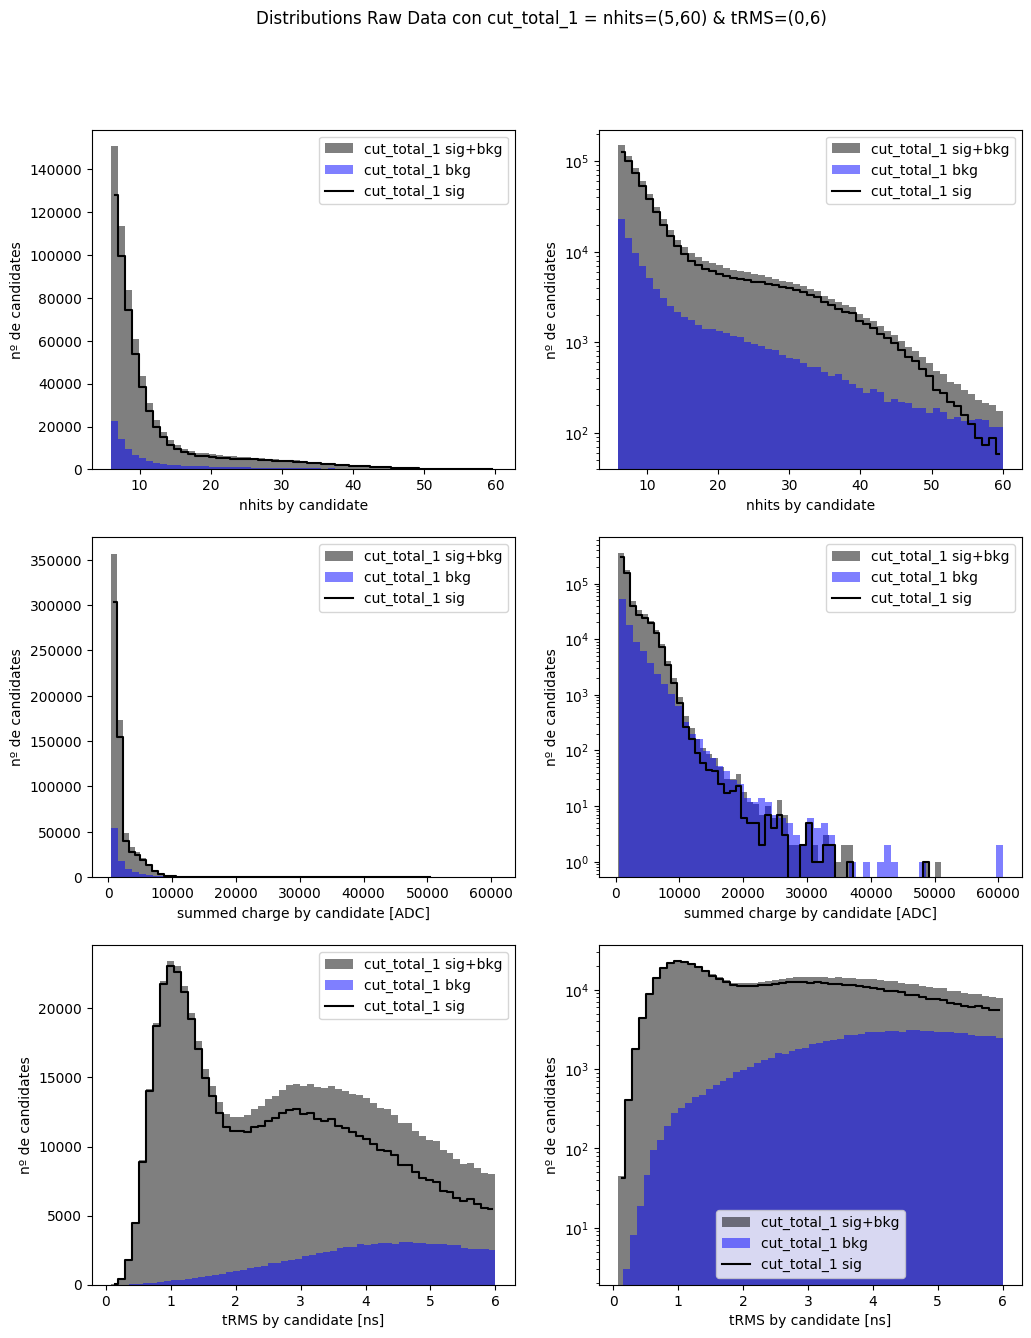

In [94]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits_cut_total_1, edges_sig_nhits_cut_total_1, _ = plt.hist(total_nhits_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_total_1, edges_bkg_nhits_cut_total_1, _ = plt.hist(total_nhits_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_nhits_cut_total_1 = (edges_sig_nhits_cut_total_1[:-1] + edges_sig_nhits_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_total_1, counts_sig_nhits_cut_total_1 - counts_bkg_nhits_cut_total_1, where="mid", label="cut_total_1 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(2)
counts_sig_nhits_cut_total_1, edges_sig_nhits_cut_total_1, _ = plt.hist(total_nhits_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_total_1, edges_bkg_nhits_cut_total_1, _ = plt.hist(total_nhits_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_nhits_cut_total_1 = (edges_sig_nhits_cut_total_1[:-1] + edges_sig_nhits_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_total_1, counts_sig_nhits_cut_total_1 - counts_bkg_nhits_cut_total_1, where="mid", label="cut_total_1 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")


subplot(3)
counts_sig_charge_cut_total_1, edges_sig_charge_cut_total_1, _ = plt.hist(total_charge_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_total_1, edges_bkg_charge_cut_total_1, _ = plt.hist(total_charge_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_charge_cut_total_1 = (edges_sig_charge_cut_total_1[:-1] + edges_sig_charge_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_total_1, counts_sig_charge_cut_total_1 - counts_bkg_charge_cut_total_1, where="mid", label="cut_total_1 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(4)
counts_sig_charge_cut_total_1, edges_sig_charge_cut_total_1, _ = plt.hist(total_charge_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_total_1, edges_bkg_charge_cut_total_1, _ = plt.hist(total_charge_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_charge_cut_total_1 = (edges_sig_charge_cut_total_1[:-1] + edges_sig_charge_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_total_1, counts_sig_charge_cut_total_1 - counts_bkg_charge_cut_total_1, where="mid", label="cut_total_1 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")

subplot(5)#para trms
counts_sig_trms_cut_total_1, edges_sig_trms_cut_total_1, _ = plt.hist(total_trms_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_total_1, edges_bkg_trms_cut_total_1, _ = plt.hist(total_trms_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_trms_cut_total_1 = (edges_sig_trms_cut_total_1[:-1] + edges_sig_trms_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_total_1, counts_sig_trms_cut_total_1 - counts_bkg_trms_cut_total_1, where="mid", label="cut_total_1 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(6)#para trms
counts_sig_trms_cut_total_1, edges_sig_trms_cut_total_1, _ = plt.hist(total_trms_by_candidate_sig_cut_total_1, 55, histtype="stepfilled", alpha=0.5, label="cut_total_1 sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_total_1, edges_bkg_trms_cut_total_1, _ = plt.hist(total_trms_by_candidate_bkg_cut_total_1, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_1 bkg")

bin_centers_trms_cut_total_1 = (edges_sig_trms_cut_total_1[:-1] + edges_sig_trms_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_total_1, counts_sig_trms_cut_total_1 - counts_bkg_trms_cut_total_1, where="mid", label="cut_total_1 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")

plt.suptitle("Distributions Raw Data con cut_total_1 = nhits=(5,60) & tRMS=(0,6)", y=0.96)


## Cortes nhits + charge + tRMS por candidate

In [ ]:
#cut_total_2 = corte de 5 a 60 nhits + corte de 0 a 10000 [ADC] en charge + corte de 0 a 6 [ns] en trms, la aplicamos en bkg y en sig+bkg

cut_total_2_bkg = (total_nhits_by_candidate_bkg > 5) & (total_nhits_by_candidate_bkg <= 60) & (total_charge_by_candidate_bkg > 0) & (total_charge_by_candidate_bkg <= 10000) & (total_trms_by_candidate_bkg > 0) & (total_trms_by_candidate_bkg <= 6)
cut_total_2_sig = (total_nhits_by_candidate_sig > 5) & (total_nhits_by_candidate_sig <= 60) & (total_charge_by_candidate_sig > 0) & (total_charge_by_candidate_sig <= 10000) & (total_trms_by_candidate_sig > 0) & (total_trms_by_candidate_sig <= 6)

total_nhits_by_candidate_bkg_cut_total_2 = total_nhits_by_candidate_bkg[cut_total_2_bkg]
total_trms_by_candidate_bkg_cut_total_2 = total_trms_by_candidate_bkg[cut_total_2_bkg]
total_charge_by_candidate_bkg_cut_total_2 = total_charge_by_candidate_bkg[cut_total_2_bkg]

total_nhits_by_candidate_sig_cut_total_2 = total_nhits_by_candidate_sig[cut_total_2_sig]
total_trms_by_candidate_sig_cut_total_2 = total_trms_by_candidate_sig[cut_total_2_sig]
total_charge_by_candidate_sig_cut_total_2 = total_charge_by_candidate_sig[cut_total_2_sig]

Text(0.5, 0.96, 'Distributions Raw Data con cut_total_2 = nhits=(5,60) & charge=(0,10000) & tRMS=(0,6)')

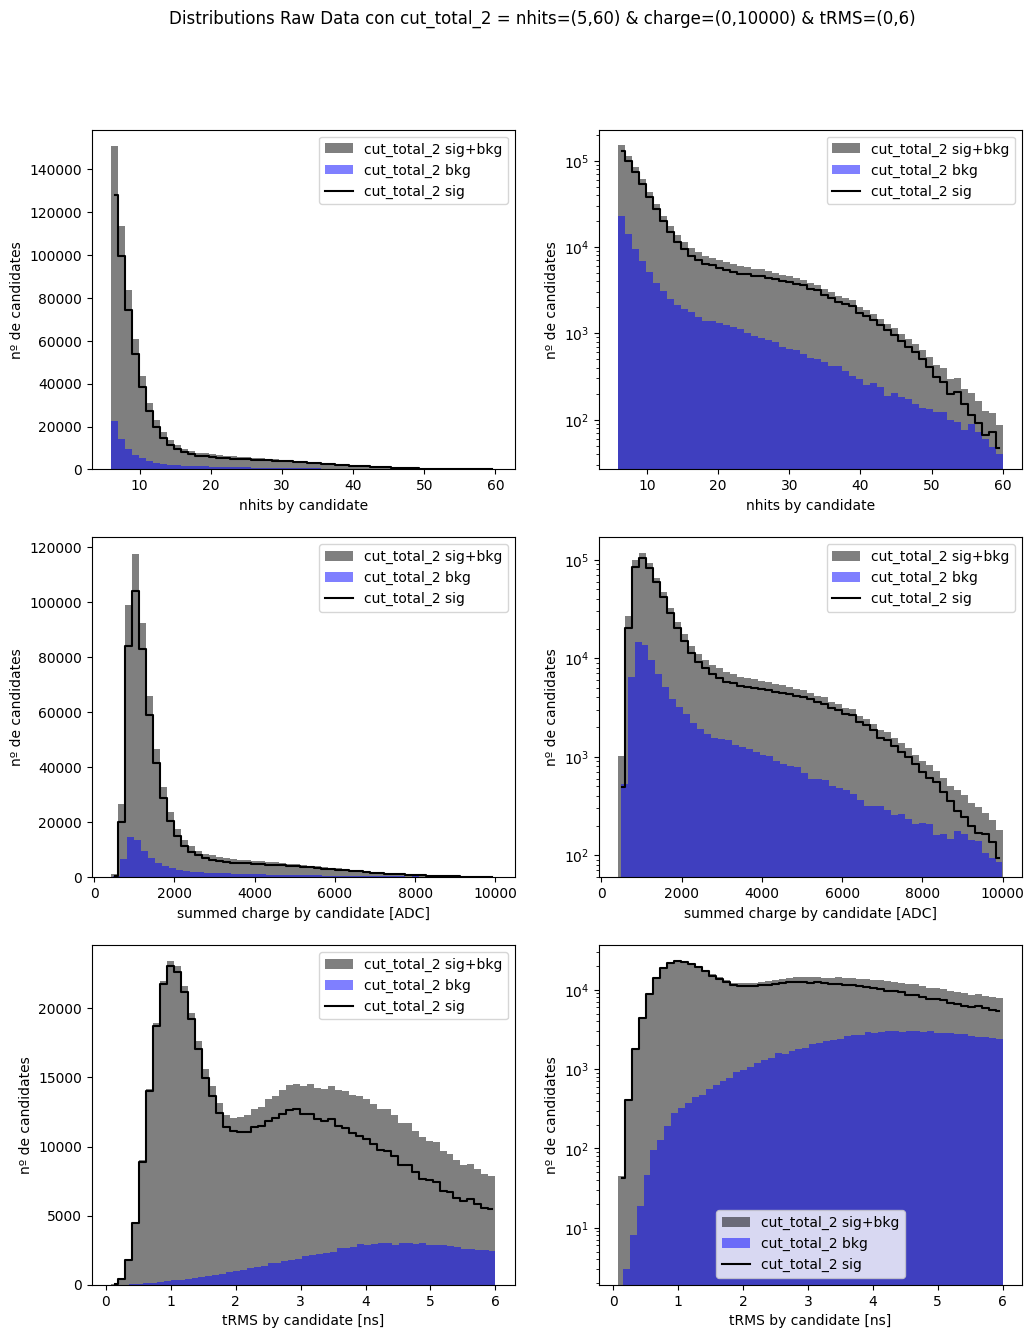

In [96]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits_cut_total_2, edges_sig_nhits_cut_total_2, _ = plt.hist(total_nhits_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_total_2, edges_bkg_nhits_cut_total_2, _ = plt.hist(total_nhits_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_nhits_cut_total_2 = (edges_sig_nhits_cut_total_2[:-1] + edges_sig_nhits_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_total_2, counts_sig_nhits_cut_total_2 - counts_bkg_nhits_cut_total_2, where="mid", label="cut_total_2 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(2)
counts_sig_nhits_cut_total_2, edges_sig_nhits_cut_total_2, _ = plt.hist(total_nhits_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_cut_total_2, edges_bkg_nhits_cut_total_2, _ = plt.hist(total_nhits_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_nhits_cut_total_2 = (edges_sig_nhits_cut_total_2[:-1] + edges_sig_nhits_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_cut_total_2, counts_sig_nhits_cut_total_2 - counts_bkg_nhits_cut_total_2, where="mid", label="cut_total_2 sig", color="k") ;

plt.xlabel("nhits by candidate")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")


subplot(3)
counts_sig_charge_cut_total_2, edges_sig_charge_cut_total_2, _ = plt.hist(total_charge_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_total_2, edges_bkg_charge_cut_total_2, _ = plt.hist(total_charge_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_charge_cut_total_2 = (edges_sig_charge_cut_total_2[:-1] + edges_sig_charge_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_total_2, counts_sig_charge_cut_total_2 - counts_bkg_charge_cut_total_2, where="mid", label="cut_total_2 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(4)
counts_sig_charge_cut_total_2, edges_sig_charge_cut_total_2, _ = plt.hist(total_charge_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 bins según nhits
counts_bkg_charge_cut_total_2, edges_bkg_charge_cut_total_2, _ = plt.hist(total_charge_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_charge_cut_total_2 = (edges_sig_charge_cut_total_2[:-1] + edges_sig_charge_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_cut_total_2, counts_sig_charge_cut_total_2 - counts_bkg_charge_cut_total_2, where="mid", label="cut_total_2 sig", color="k") 

plt.xlabel("summed charge by candidate [ADC]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")

subplot(5)#para trms
counts_sig_trms_cut_total_2, edges_sig_trms_cut_total_2, _ = plt.hist(total_trms_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_total_2, edges_bkg_trms_cut_total_2, _ = plt.hist(total_trms_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_trms_cut_total_2 = (edges_sig_trms_cut_total_2[:-1] + edges_sig_trms_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_total_2, counts_sig_trms_cut_total_2 - counts_bkg_trms_cut_total_2, where="mid", label="cut_total_2 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("linear")

subplot(6)#para trms
counts_sig_trms_cut_total_2, edges_sig_trms_cut_total_2, _ = plt.hist(total_trms_by_candidate_sig_cut_total_2, 55, histtype="stepfilled", alpha=0.5, label="cut_total_2 sig+bkg") #55 bins según nhits
counts_bkg_trms_cut_total_2, edges_bkg_trms_cut_total_2, _ = plt.hist(total_trms_by_candidate_bkg_cut_total_2, 55, histtype = "stepfilled" ,alpha=0.5, label="cut_total_2 bkg")

bin_centers_trms_cut_total_2 = (edges_sig_trms_cut_total_2[:-1] + edges_sig_trms_cut_total_2 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_cut_total_2, counts_sig_trms_cut_total_2 - counts_bkg_trms_cut_total_2, where="mid", label="cut_total_2 sig", color="k") 

plt.xlabel("tRMS by candidate [ns]")
plt.ylabel("nº de candidates")
plt.legend()
plt.yscale("log")

plt.suptitle("Distributions Raw Data con cut_total_2 = nhits=(5,60) & charge=(0,10000) & tRMS=(0,6)", y=0.96)


# Corrección a los tiempos calibrados en cada candidate

*Trigger*: es el mecanismo q decide cuándo guardar datos (porq al detector le llegan tantos que no se puede guardar todo). En nuestro experimento el trigger es código, pero podría ser también hardware

*Readout window*: intervalo de $t$ en el q el WCTE guarda los hits después del trigger. Diego la definió como 20 [ns]. Entonces, un evento es el conjunto de hits registrados en una readout window, mientra que un candidato es una posible señal física detectada dentro de un evento.

*Dead time*: intervalo de $t$ desupués de registrar una señal en el que el WCTE no puede registrar otra. Diego la definió como 20 [ns]. Al coincidir dead time = readout window, evitamos que los eventos estén solapados, i.e., dos eventos distintos dentro de la misma readout window serían difíciles de separar

In [33]:
#quiero insertar una nueva columna en data_bkg y data_sig. En esta columna irán los tiempos en los que llega el hit respecto del primero de SU candidateo
#Tendré que hacer una resta del hit_pmt_calibrated_times de los hits respecto del primero, para cada hit en cada candidateo

hit_pmt_calibrated_times_by_candidate_bkg = data_by_candidate_bkg["hit_pmt_calibrated_times"]
hit_pmt_calibrated_times_by_candidate_sig = data_by_candidate_sig["hit_pmt_calibrated_times"]

def correct_times(times):
    t0 = times.iloc[0]  #primer hit del candidateo como ref
    return times - t0

corrected_times_bkg = hit_pmt_calibrated_times_by_candidate_bkg.apply(correct_times).reset_index(level=0, drop=True)
corrected_times_sig = hit_pmt_calibrated_times_by_candidate_sig.apply(correct_times).reset_index(level=0, drop=True)
#tengo q usar sí o sí .reset_index(level=0, drop=True) para que corrected_times tenga el mismo índice que data_bkg data_sig, fila por fila
#level=0 elimina el índice del grupo (candidate_id)
#drop=True no lo convierte en columna, sólo ajusta el índice

data_bkg["pmt_hit_calibrated_times_corrected"] = corrected_times_bkg
data_sig["pmt_hit_calibrated_times_corrected"] = corrected_times_sig



In [34]:
data_bkg

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,209221.084343,103.0,19,12,373,0.000000
1,1,0,0,209223.152791,119.0,19,4,365,2.068448
2,2,0,0,209233.144440,175.0,19,10,371,12.060098
3,3,0,1,209588.321986,97.0,100,0,1900,0.000000
4,4,0,1,209590.743413,104.0,101,13,1932,2.421427
...,...,...,...,...,...,...,...,...,...
18253236,18253236,83110,645853,247287.565400,180.0,3,18,75,3.302078
18253237,18253237,83110,645854,331560.611688,141.0,8,1,153,0.000000
18253238,18253238,83110,645854,331562.449078,97.0,2,1,39,1.837390
18253239,18253239,83110,645854,331566.346411,132.0,52,10,998,5.734723


In [35]:
data_sig

,Unnamed: 0,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,pmt_hit_calibrated_times_corrected
0,0,0,0,63479.663380,83.0,1,5,24,0.000000
1,1,0,0,63480.392541,133.0,46,12,886,0.729161
2,2,0,0,63496.106182,180.0,8,5,157,16.442802
3,3,0,1,65913.196181,75.0,69,17,1328,0.000000
4,4,0,1,65913.202297,137.0,70,1,1331,0.006115
...,...,...,...,...,...,...,...,...,...
30143260,30143260,83111,1955360,494925.804957,111.0,88,9,1681,2.830127
30143261,30143261,83111,1955360,494926.207864,215.0,90,16,1726,3.233033
30143262,30143262,83111,1955360,494926.448105,161.0,88,8,1680,3.473275
30143263,30143263,83111,1955360,494926.550472,61.0,89,17,1708,3.575641


## mean_time

Text(0.5, 0.98, 'Comparison mean_times por candidate linear yscale')

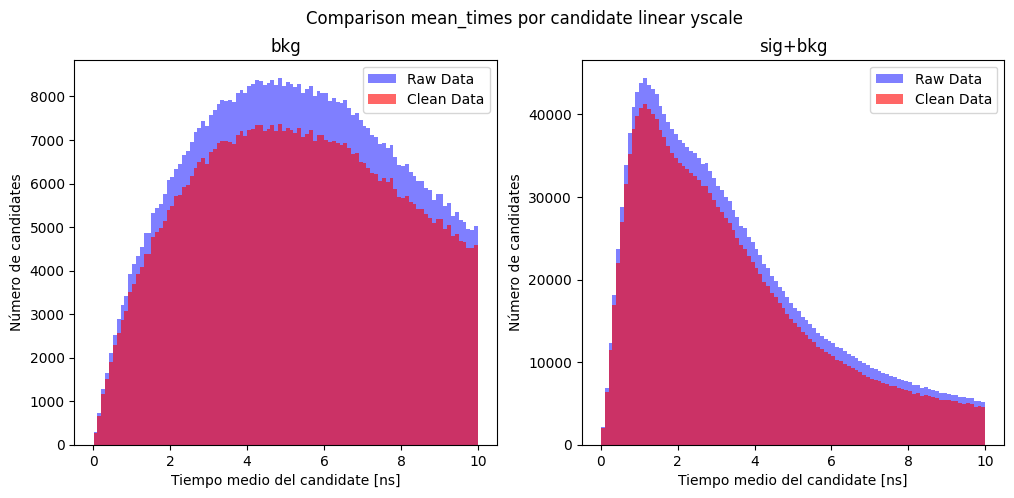

In [147]:
mean_times_by_candidate_bkg = data_by_candidate_bkg["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_candidate_sig = data_by_candidate_sig["pmt_hit_calibrated_times_corrected"].mean()

mean_times_by_candidate_bkg_clean = mean_times_by_candidate_bkg.drop(combined_series_bkg.index)
mean_times_by_candidate_sig_clean = mean_times_by_candidate_sig.drop(combined_series_sig.index)

subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.5)
plt.hist(mean_times_by_candidate_bkg_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data",alpha=0.5)
plt.hist(mean_times_by_candidate_sig_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate linear yscale")

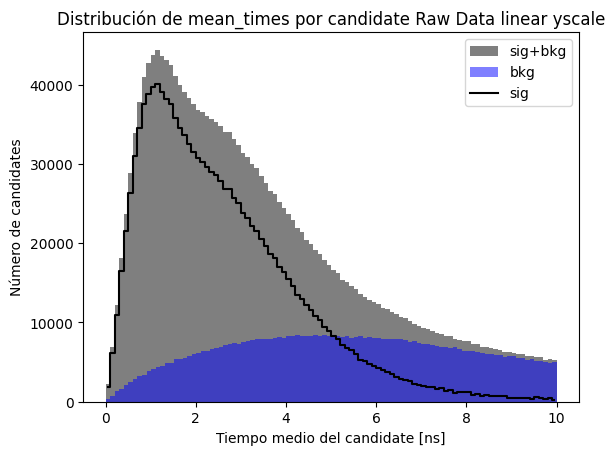

In [37]:
counts_sig_mean_times, edges_sig_mean_times, _ = plt.hist(mean_times_by_candidate_sig, 100, color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_mean_times, edges_bkg_mean_times, _ = plt.hist(mean_times_by_candidate_bkg, 100, color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_mean_times = (edges_sig_mean_times[:-1] + edges_sig_mean_times [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_mean_times, counts_sig_mean_times - counts_bkg_mean_times, where="mid", label="sig", color="k") ;

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("Distribución de mean_times por candidate Raw Data linear yscale")
plt.yscale("linear")
plt.legend()

### Aplicamos cortes y calculamos el mean_time

#### Cuts nhits: cut_5, cut_10

Text(0.5, 0.98, 'Comparison mean_times por candidate')

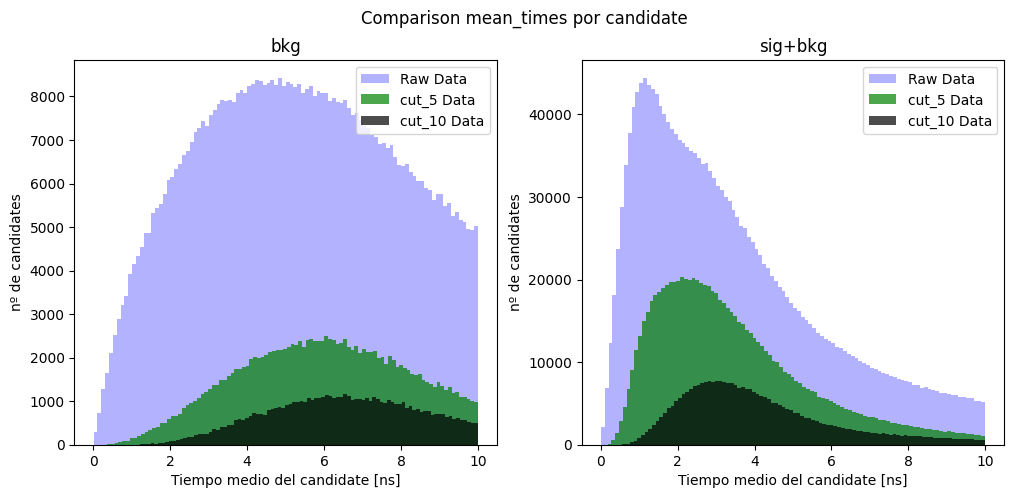

In [123]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_5 y cut_10

mean_times_by_candidate_bkg_cut_5 = mean_times_by_candidate_bkg[cut_5_bkg]
mean_times_by_candidate_sig_cut_5 = mean_times_by_candidate_sig[cut_5_sig]

mean_times_by_candidate_bkg_cut_10 = mean_times_by_candidate_bkg[cut_10_bkg]
mean_times_by_candidate_sig_cut_10 = mean_times_by_candidate_sig[cut_10_sig]

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_5, bins=100, color="g",label="cut_5 Data", alpha=0.7)
plt.hist(mean_times_by_candidate_bkg_cut_10, bins=100, color="k",label="cut_10 Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_5, bins=100, color="g",label="cut_5 Data", alpha=0.7)
plt.hist(mean_times_by_candidate_sig_cut_10, bins=100, color="k",label="cut_10 Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

#### Cuts charge: cut_charge

Text(0.5, 0.98, 'Comparison mean_times por candidate')

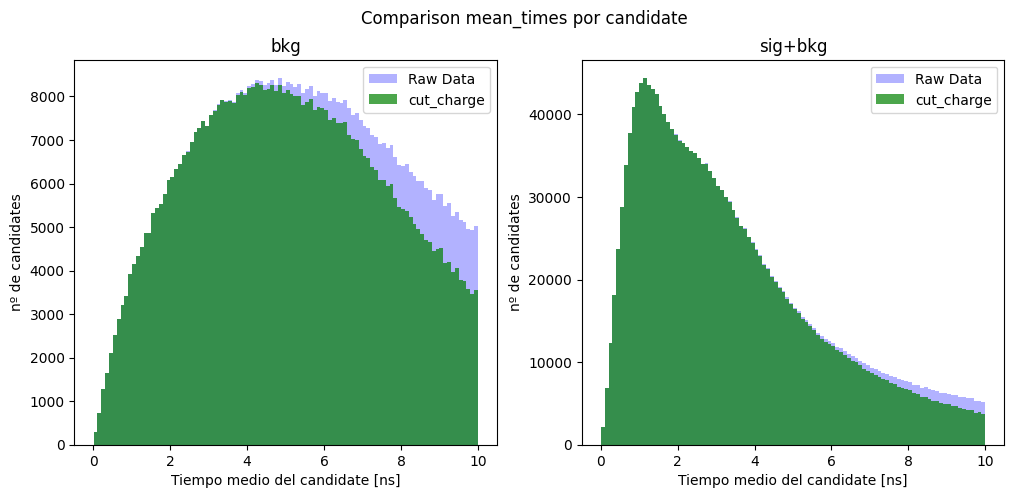

In [124]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_charge

mean_times_by_candidate_bkg_cut_charge = mean_times_by_candidate_bkg[cut_charge_bkg]
mean_times_by_candidate_sig_cut_charge = mean_times_by_candidate_sig[cut_charge_sig]

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_charge, bins=100, color="g",label="cut_charge", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_charge, bins=100, color="g",label="cut_charge", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

#### Cuts tRMS: cut_trms

Text(0.5, 0.98, 'Comparison mean_times por candidate')

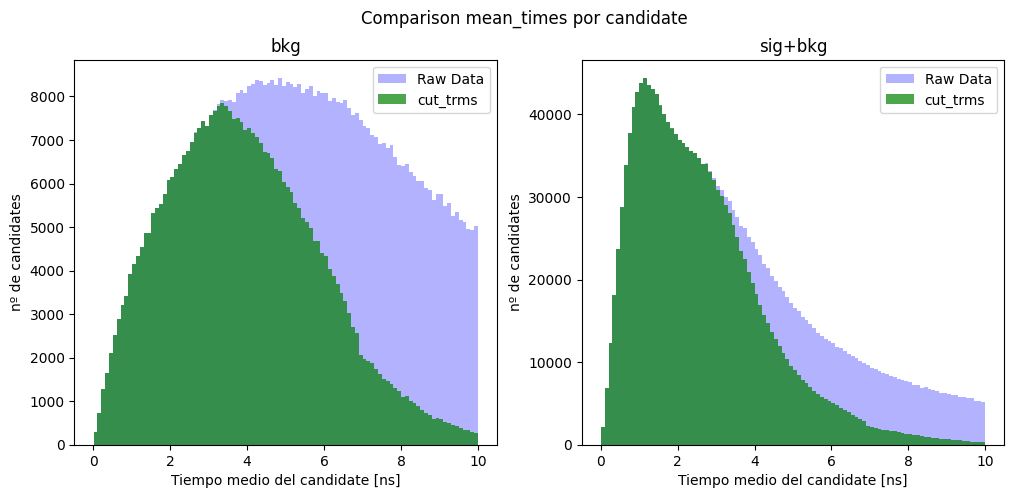

In [125]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_trms

mean_times_by_candidate_bkg_cut_trms = mean_times_by_candidate_bkg[cut_trms_bkg]
mean_times_by_candidate_sig_cut_trms = mean_times_by_candidate_sig[cut_trms_sig]

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_trms, bins=100, color="g",label="cut_trms", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_trms, bins=100, color="g",label="cut_trms", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

#### Cuts nhits + tRMS: cut_total_1

Text(0.5, 0.98, 'Comparison mean_times por candidate')

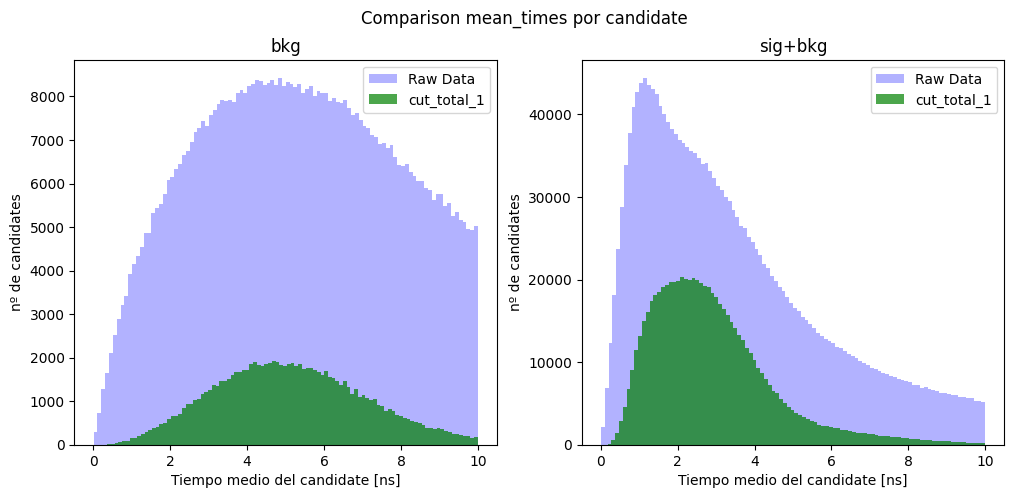

In [130]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_total_1

mean_times_by_candidate_bkg_cut_total_1 = mean_times_by_candidate_bkg[cut_total_1_bkg]
mean_times_by_candidate_sig_cut_total_1 = mean_times_by_candidate_sig[cut_total_1_sig]

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_total_1, bins=100, color="g",label="cut_total_1", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_total_1, bins=100, color="g",label="cut_total_1", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

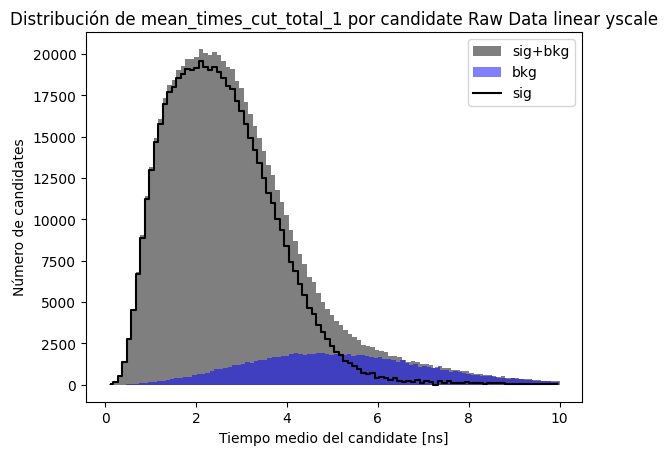

In [145]:
counts_sig_mean_times_cut_total_1, edges_sig_mean_times_cut_total_1, _ = plt.hist(mean_times_by_candidate_sig_cut_total_1, 100, color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_mean_times_cut_total_1, edges_bkg_mean_times_cut_total_1, _ = plt.hist(mean_times_by_candidate_bkg_cut_total_1, 100, color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_mean_times_cut_total_1 = (edges_sig_mean_times_cut_total_1[:-1] + edges_sig_mean_times_cut_total_1 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_mean_times_cut_total_1, counts_sig_mean_times_cut_total_1 - counts_bkg_mean_times_cut_total_1, where="mid", label="sig", color="k") ;

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("Distribución de mean_times_cut_total_1 por candidate Raw Data linear yscale")
plt.yscale("linear")
plt.legend()

#### Cuts nhits + tRMS: cut_total_2

Text(0.5, 0.98, 'Comparison mean_times por candidate')

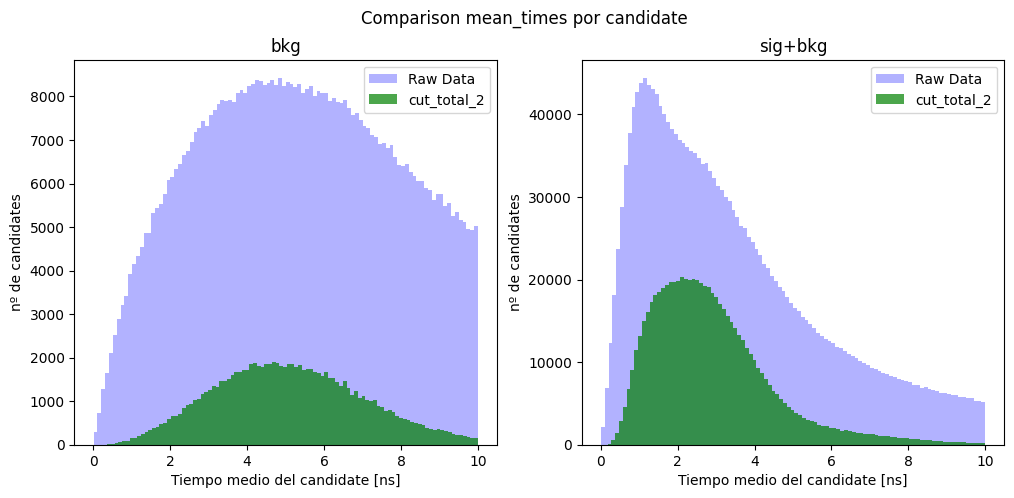

In [133]:
#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_total_2

mean_times_by_candidate_bkg_cut_total_2 = mean_times_by_candidate_bkg[cut_total_2_bkg]
mean_times_by_candidate_sig_cut_total_2 = mean_times_by_candidate_sig[cut_total_2_sig]

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_total_2, bins=100, color="g",label="cut_total_2", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_total_2, bins=100, color="g",label="cut_total_2", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate")

### RECAP mean_time con cuts

Text(0.5, 0.9, 'Comparison mean_times por candidate linear yscale')

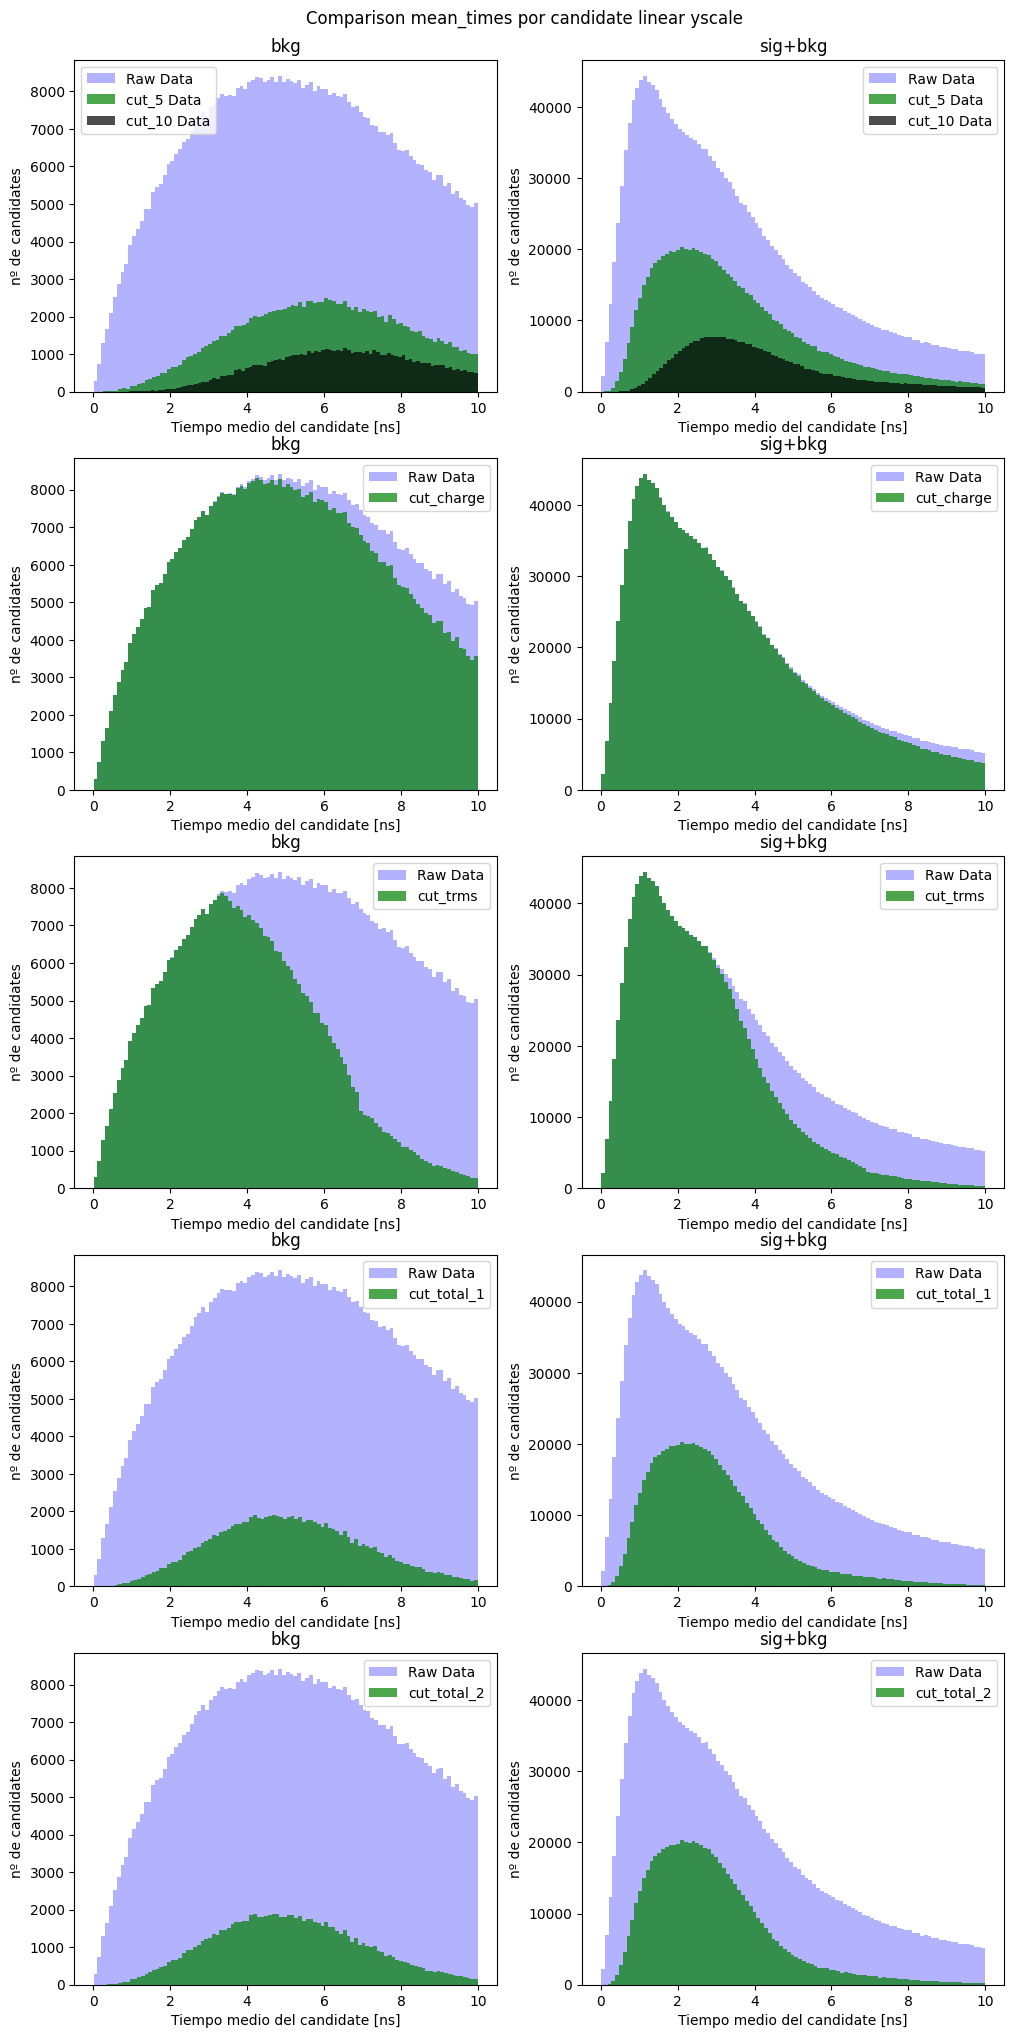

In [153]:
subplot = pltext.canvas(10)
for i in [1, 2,3,4,5,6,7,8,9,10]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_5, bins=100, color="g",label="cut_5 Data", alpha=0.7)
plt.hist(mean_times_by_candidate_bkg_cut_10, bins=100, color="k",label="cut_10 Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_5, bins=100, color="g",label="cut_5 Data", alpha=0.7)
plt.hist(mean_times_by_candidate_sig_cut_10, bins=100, color="k",label="cut_10 Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

subplot(3)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_charge, bins=100, color="g",label="cut_charge", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(4)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_charge, bins=100, color="g",label="cut_charge", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

subplot(5)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_trms, bins=100, color="g",label="cut_trms", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(6)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_trms, bins=100, color="g",label="cut_trms", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

subplot(7)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_total_1, bins=100, color="g",label="cut_total_1", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(8)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_total_1, bins=100, color="g",label="cut_total_1", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

subplot(9)
plt.hist(mean_times_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_bkg_cut_total_2, bins=100, color="g",label="cut_total_2", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(10)
plt.hist(mean_times_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(mean_times_by_candidate_sig_cut_total_2, bins=100, color="g",label="cut_total_2", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por candidate linear yscale", y=0.9)

## Tamaño temporal del candidato: deltat

Ahora calculamos $\Delta t$=tiempo en el que llega el último hit - tiempo en el que llega el primero AL CANDIDATE, osea $\Delta t$ es el tamaño del candidate.

Text(0.5, 0.98, 'Comparison deltat por candidate linear yscale')

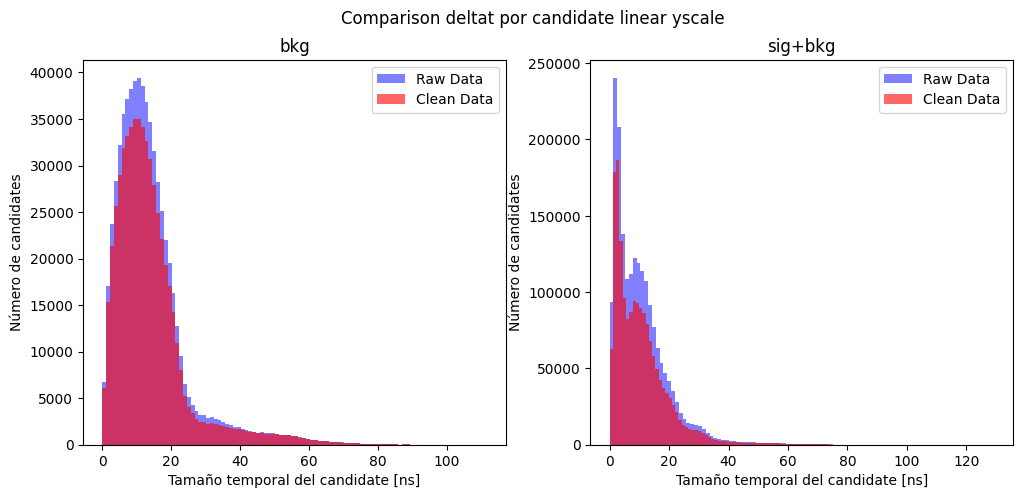

In [150]:
deltat_by_candidate_bkg = data_by_candidate_bkg["pmt_hit_calibrated_times_corrected"].last()    #level 0 es el índice candidate_id
deltat_by_candidate_sig = data_by_candidate_sig["pmt_hit_calibrated_times_corrected"].last()   

deltat_by_candidate_bkg_clean = deltat_by_candidate_bkg.drop(combined_series_bkg.index)
deltat_by_candidate_sig_clean = deltat_by_candidate_sig.drop(combined_series_sig.index)

subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
plt.hist(deltat_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.5)
plt.hist(deltat_by_candidate_bkg_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(deltat_by_candidate_sig, 100, color="b", label="Raw Data",alpha=0.5)
plt.hist(deltat_by_candidate_sig_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison deltat por candidate linear yscale")

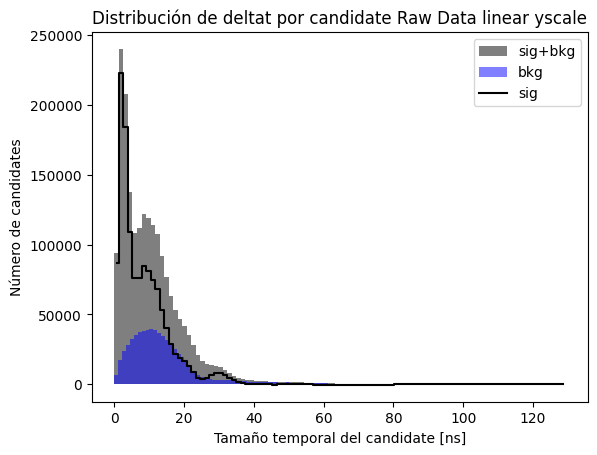

In [155]:
counts_sig_deltat, edges_sig_deltat, _ = plt.hist(deltat_by_candidate_sig, 100, color="k", histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_deltat, edges_bkg_deltat, _ = plt.hist(deltat_by_candidate_bkg, 100, color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_deltat = (edges_sig_deltat[:-1] + edges_sig_deltat [1:])/2 #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_deltat, counts_sig_deltat - counts_bkg_deltat, where="mid", label="sig", color="k") ;

plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("Distribución de deltat por candidate Raw Data linear yscale")
plt.yscale("linear")

plt.legend()

Text(0.5, 0.98, 'Correlación nhits vs tamaño del candidate')

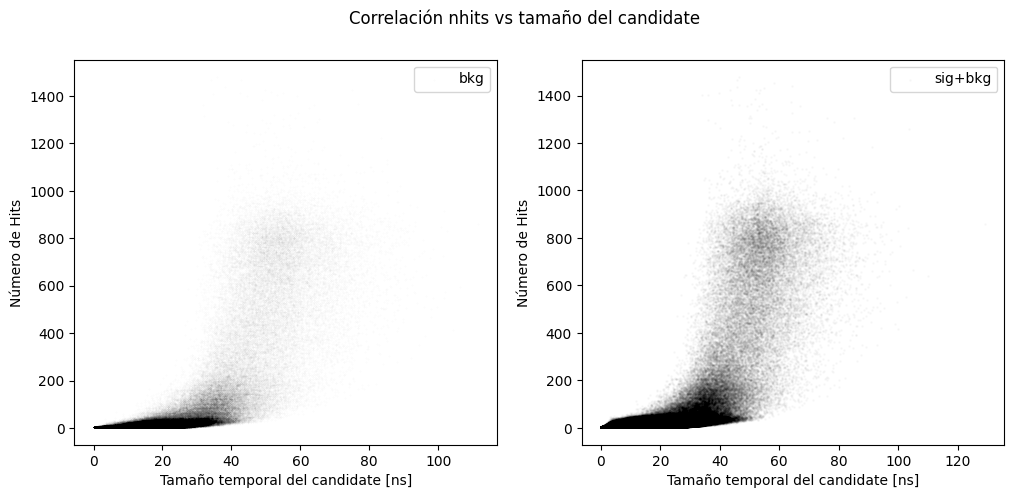

In [39]:
nhits_in_deltat_sig = data_by_candidate_sig.size()  #cuento cuántos hits tiene cada candidate
nhits_in_deltat_bkg = data_by_candidate_bkg.size()

#nhits y deltat_by_candidate tendrán el mismo índice (candidate_id), por lo que matplotlib los alineará perfectamente

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(deltat_by_candidate_bkg, nhits_in_deltat_bkg, color="k", alpha=0.02, s=0.1, label="bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.legend()

subplot(2)
plt.scatter(deltat_by_candidate_sig, nhits_in_deltat_sig, color="k", alpha=0.02, s=1, label="sig+bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.legend(loc="best")


plt.suptitle("Correlación nhits vs tamaño del candidate")

Text(0.5, 0.98, 'Correlación nhits vs tamaño del candidate')

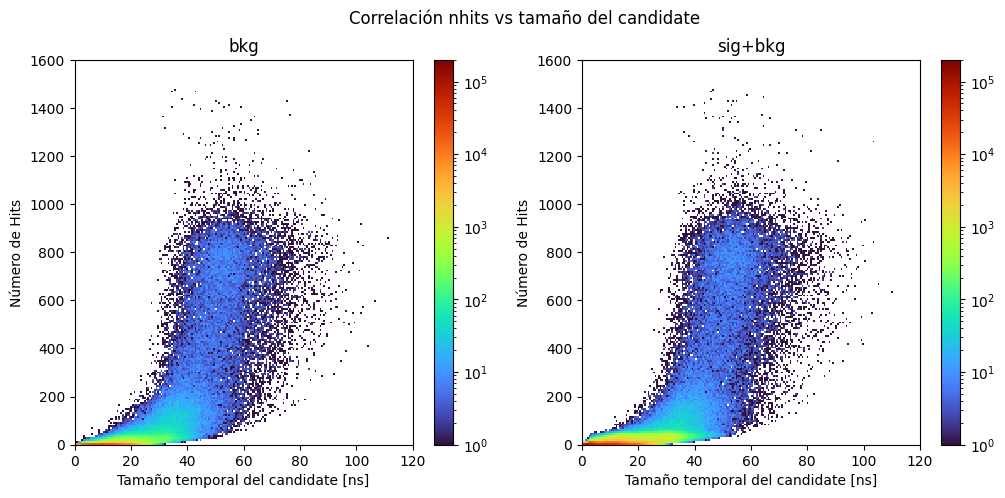

In [40]:
import matplotlib.colors as colors
subplot = pltext.canvas(2)

bins = 200
axis_range = [[0, 120], [0, 1600]] # [[xmin,xmax], [ymin,ymax]]

c_min = 1; c_max = 2e5  #para igualar las barras de color

subplot(1)
plt.hist2d(deltat_by_candidate_bkg, nhits_in_deltat_bkg, bins=bins, range=axis_range, norm=colors.LogNorm(vmin=c_min, vmax=c_max), cmap="turbo")    #cmap="turbo" para q sea más chuli
plt.colorbar()
plt.title("bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.title("bkg")

subplot(2)
plt.hist2d(deltat_by_candidate_sig, nhits_in_deltat_sig, bins=bins, range=axis_range, norm=colors.LogNorm(vmin=c_min, vmax=c_max), cmap="turbo")
plt.colorbar()
plt.title("sig+bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.title("sig+bkg")

plt.suptitle("Correlación nhits vs tamaño del candidate")

### Cut en deltat: cut_deltat=(0,40), mmm creo que esto no sirve

Text(0.5, 0.98, 'Comparison deltat con cut_deltat=(0,40) linear yscale')

<Figure size 1200x500 with 0 Axes>

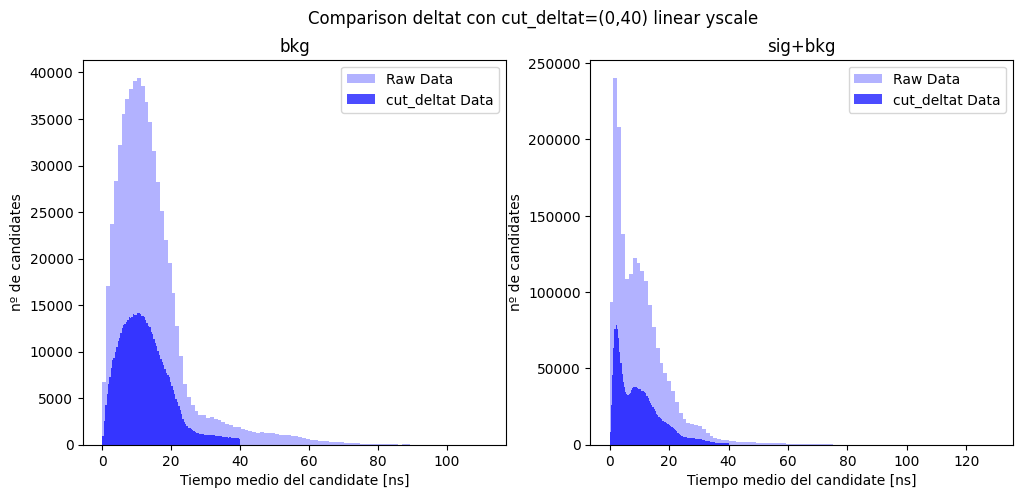

In [ ]:
cut_deltat_bkg = (deltat_by_candidate_bkg > 0) & (deltat_by_candidate_bkg <= 40)
cut_deltat_sig = (deltat_by_candidate_sig > 0) & (deltat_by_candidate_sig <= 40)  #no puedo usar la misma máscara para los dos porq son series diferentes

deltat_by_candidate_sig_cut_deltat = deltat_by_candidate_sig[cut_deltat_sig]
deltat_by_candidate_bkg_cut_deltat = deltat_by_candidate_bkg[cut_deltat_bkg]

total_nhits_by_candidate_sig_cut_deltat = total_nhits_by_candidate_sig.loc[deltat_by_candidate_sig_cut_deltat.index]
total_nhits_by_candidate_bkg_cut_deltat = total_nhits_by_candidate_bkg.loc[deltat_by_candidate_bkg_cut_deltat.index]

total_trms_by_candidate_sig_cut_deltat = total_trms_by_candidate_sig.loc[deltat_by_candidate_sig_cut_deltat.index]
total_trms_by_candidate_bkg_cut_deltat = total_trms_by_candidate_bkg.loc[deltat_by_candidate_bkg_cut_deltat.index]

#hacemos lo mismo pero SÓLO para los candidates que pasan el cut de cut_deltat

deltat_by_candidate_bkg_cut_deltat = deltat_by_candidate_bkg[cut_deltat_bkg]
deltat_by_candidate_sig_cut_deltat = deltat_by_candidate_sig[cut_deltat_sig]


subplot = pltext.canvas(2)
subplot = pltext.canvas(2)
for i in [1, 2]:
    subplot(i)
    plt.yscale("linear")

subplot(1)
plt.hist(deltat_by_candidate_bkg, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(deltat_by_candidate_bkg_cut_deltat, bins=100, color="b",label="cut_deltat Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(deltat_by_candidate_sig, 100, color="b", label="Raw Data", alpha=0.3)
plt.hist(deltat_by_candidate_sig_cut_deltat, bins=100, color="b",label="cut_deltat Data", alpha=0.7)

plt.xlabel("Tiempo medio del candidate [ns]")
plt.ylabel("nº de candidates")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison deltat con cut_deltat=(0,40) linear yscale")

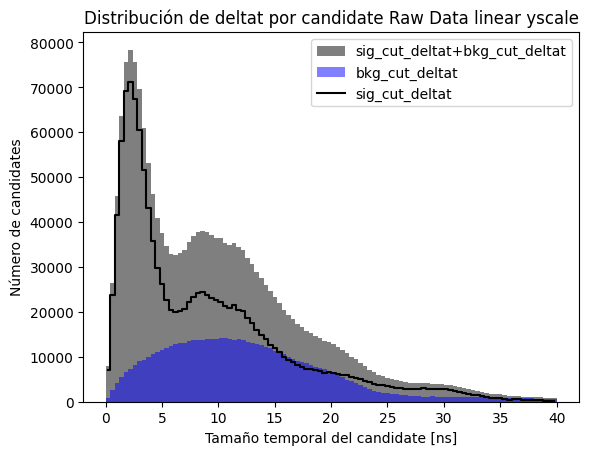

In [167]:
counts_sig_cut_deltat_deltat, edges_sig_cut_deltat_deltat, _ = plt.hist(deltat_by_candidate_sig_cut_deltat, 100, color="k", histtype="stepfilled", alpha=0.5, label="sig_cut_deltat+bkg_cut_deltat")
counts_bkg_cut_deltat_deltat, edges_bkg_cut_deltat_deltat, _ = plt.hist(deltat_by_candidate_bkg_cut_deltat, 100, color="b", histtype = "stepfilled" ,alpha=0.5, label="bkg_cut_deltat")

bin_centers_deltat = (edges_sig_cut_deltat_deltat[:-1] + edges_sig_cut_deltat_deltat [1:])/2 #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_deltat, counts_sig_cut_deltat_deltat - counts_bkg_cut_deltat_deltat, where="mid", label="sig_cut_deltat", color="k") ;

plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de candidates")
plt.title("Distribución de deltat por candidate Raw Data linear yscale")
plt.yscale("linear")

plt.legend()

Text(0.5, 0.98, 'Correlación nhits vs tamaño del candidate con cut deltat')

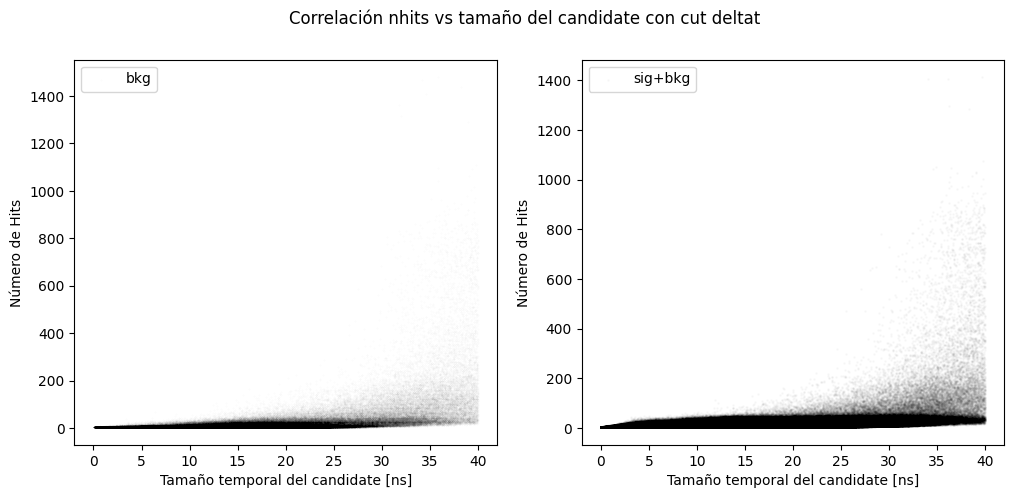

In [169]:
nhits_in_deltat_sig_cut_deltat = total_nhits_by_candidate_sig.loc[deltat_by_candidate_sig_cut_deltat.index]
nhits_in_deltat_bkg_cut_deltat = total_nhits_by_candidate_bkg.loc[deltat_by_candidate_bkg_cut_deltat.index]

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(deltat_by_candidate_bkg_cut_deltat, nhits_in_deltat_bkg_cut_deltat, color="k", alpha=0.02, s=0.1, label="bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.legend()

subplot(2)
plt.scatter(deltat_by_candidate_sig_cut_deltat, nhits_in_deltat_sig_cut_deltat, color="k", alpha=0.02, s=1, label="sig+bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.legend(loc="best")


plt.suptitle("Correlación nhits vs tamaño del candidate con cut deltat")

Text(0.5, 0.98, 'Correlación nhits vs tamaño del candidate')

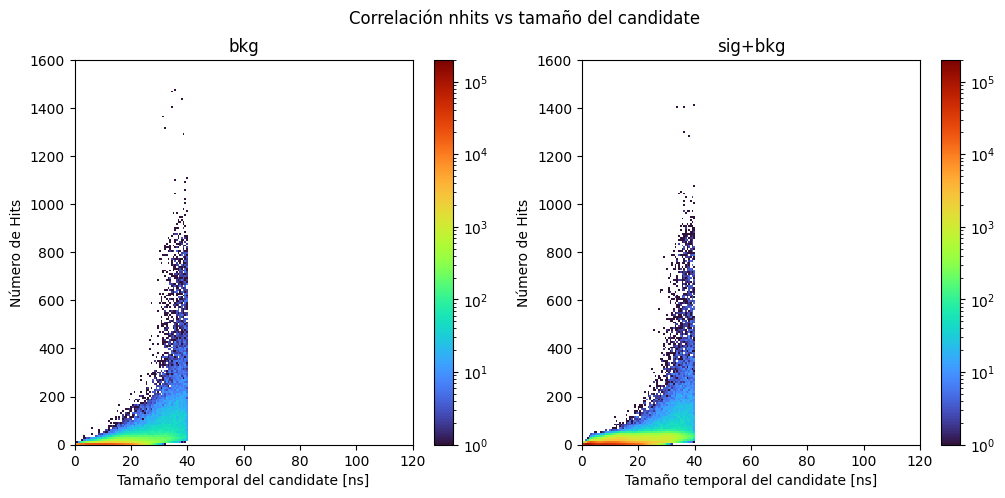

In [170]:
subplot = pltext.canvas(2)

bins = 200
axis_range = [[0, 120], [0, 1600]] # [[xmin,xmax], [ymin,ymax]]

c_min = 1; c_max = 2e5  #para igualar las barras de color

subplot(1)
plt.hist2d(deltat_by_candidate_bkg_cut_deltat, nhits_in_deltat_bkg_cut_deltat, bins=bins, range=axis_range, norm=colors.LogNorm(vmin=c_min, vmax=c_max), cmap="turbo")    #cmap="turbo" para q sea más chuli
plt.colorbar()
plt.title("bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.title("bkg")

subplot(2)
plt.hist2d(deltat_by_candidate_sig_cut_deltat, nhits_in_deltat_sig_cut_deltat, bins=bins, range=axis_range, norm=colors.LogNorm(vmin=c_min, vmax=c_max), cmap="turbo")
plt.colorbar()
plt.title("sig+bkg")
plt.xlabel("Tamaño temporal del candidate [ns]")
plt.ylabel("Número de Hits")
plt.title("sig+bkg")

plt.suptitle("Correlación nhits vs tamaño del candidate")

### Con Clean Data

Yo creo que no cambiarían mucho los histogramas, en todo caso tendríamps menos estadística

# Desplegable

In [50]:
import json
import pandas as pd
import numpy as np

def extract_all_pmt_positions(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    pmt_list = []
    
    # Ordenamos las llaves de mpmts para asegurar que vamos del 0 al 105 (o los que haya)
    mpmt_keys = sorted(data['mpmts'].keys(), key=int)
    
    for m_id_str in mpmt_keys:
        mpmt_info = data['mpmts'][m_id_str]
        m_loc = np.array(mpmt_info['placement']['location'])
        
        # Ordenamos las llaves de los pmts internos (0 al 18)
        pmt_keys = sorted(mpmt_info['pmts'].keys(), key=int)
        
        for p_id_str in pmt_keys:
            pmt_info = mpmt_info['pmts'][p_id_str]
            p_rel_loc = np.array(pmt_info['placement']['location'])
            
            # Posición absoluta
            p_abs_loc = m_loc + p_rel_loc
            
            # Usamos un ID global basado simplemente en el orden de aparición
            # Esto debería darte del 0 al 2013 si hay 106 mPMTs * 19 PMTs
            global_id = len(pmt_list)
            
            pmt_list.append({
                'pmt_id': global_id, 
                'x': p_abs_loc[0],
                'y': p_abs_loc[1],
                'z': p_abs_loc[2],
                'mpmt_id': int(m_id_str),
                'pmt_in_mpmt': int(p_id_str)
            })
            
    return pd.DataFrame(pmt_list)

# Ejecución
ruta_archivo = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/wcte_v11_20250513.json"
df_positions = extract_all_pmt_positions(ruta_archivo)

print(f"Total de PMTs extraídos: {len(df_positions)}")
print(df_positions.tail()) # Ver los últimos para comprobar que llega cerca del 2013

Total de PMTs extraídos: 2014
      pmt_id            x         y            z  mpmt_id  pmt_in_mpmt
2009    2009 -1317.847019  3718.924  2228.866981      105           14
2010    2010 -1251.133019  3718.924  2162.152981      105           15
2011    2011 -1160.000000  3718.924  2137.733962      105           16
2012    2012 -1068.866981  3718.924  2162.152981      105           17
2013    2013 -1002.152981  3718.924  2228.866981      105           18


In [51]:
from WCTE_event_display.EventDisplay import EventDisplay

In [52]:
# Los Datos a Plottear
n_pmts    = 2014
nhits_sig = data_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)

In [53]:
# Plot
eventDisplay.plotEventDisplay(nhits_sig, color_norm=None, style="dark_background")

NameError: name 'eventDisplay' is not defined